# A - Setup

In [1]:
import os, sys, time, warnings, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, time, warnings
import numpy as np
from sklearn.metrics import roc_auc_score
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

N_TRIALS  = 30          
TUNE_SEED = 42     

OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
SAVE_DIR   = f'{OUTPUT_DIR}/saved_models'


print("python  :", sys.version)
print("platform:", platform.platform())
print("numpy   :", np.__version__)
print("pandas  :", pd.__version__)


python  : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
platform: Linux-6.12.90+-x86_64-with-glibc2.35
numpy   : 2.0.2
pandas  : 2.3.3


In [2]:
import torch, gc
torch.cuda.empty_cache()
gc.collect()
torch.cuda.synchronize()

In [3]:
import torch
import optuna
import shap
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, confusion_matrix, classification_report,
)
from category_encoders import WOEEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier 


from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import LabelEncoder, QuantileTransformer

optuna.logging.set_verbosity(optuna.logging.WARNING)
print('Imports OK')


Imports OK


In [4]:
!pip install pytorch_tabnet 
from pytorch_tabnet.tab_model import TabNetClassifier
print('pytorch_tabnet OK')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.2 MB/s eta 0:00:00
pytorch_tabnet OK


In [5]:
!pip install tabm --break-system-packages -q
import tabm

In [6]:
!pip install entmax

---
# 1. Function


## 1.1 Evaluate metrics

In [7]:
def evaluate(model, X, y_true, label='', threshold=None):
    y_prob = model.predict_proba(X)[:, 1]
    y_true = np.array(y_true)
    auc    = roc_auc_score(y_true, y_prob)
    ap     = average_precision_score(y_true, y_prob)
    gini   = 2 * auc - 1
    fpr, tpr, thr_roc = roc_curve(y_true, y_prob)
    ks_scores   = tpr - fpr
    ks          = ks_scores.max()
    
    if threshold is not None:
        best_thresh = threshold
    else:
        best_thresh = float(thr_roc[ks_scores.argmax()])
    
    y_pred      = (y_prob >= best_thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    recall_bad     = tp / (tp + fn + 1e-8)
    recall_good    = tn / (tn + fp + 1e-8)
    precision_bad  = tp / (tp + fp + 1e-8)
    f1_bad         = 2 * precision_bad * recall_bad / (precision_bad + recall_bad + 1e-8)
    if label:
        print(f"  [{label}] AUC={auc:.4f}  Gini={gini:.4f}  KS={ks:.4f}  F1(bad)={f1_bad:.4f}")
    return dict(auc=auc, gini=gini, ks=ks, ap=ap, threshold=best_thresh,
                recall_bad=recall_bad, recall_good=recall_good,
                precision_bad=precision_bad, f1_bad=f1_bad,
                tp=int(tp), fp=int(fp), tn=int(tn), fn=int(fn))

## 1.2 Summarize

In [8]:
def summarize_results(results):
    rows = []
    for name, r in results.items():
        tr, va, te = r['train'], r['valid'], r['test']
        rows.append({
            'Model'          : name,
            'Train AUC'      : round(tr['auc'],           4),
            'Valid AUC'      : round(va['auc'],           4),
            'Test AUC'       : round(te['auc'],           4),
            'Valid KS'       : round(va['ks'],            4),
            'Test Gini'      : round(te['gini'],          4),
            'Test KS'        : round(te['ks'],            4),
            'Precision (Bad)': round(te['precision_bad'], 4),
            'Recall (Bad)'   : round(te['recall_bad'],    4),
            'Recall (Good)'  : round(te['recall_good'],   4),
            'F1 (Bad)'       : round(te['f1_bad'],        4),
            'TP': int(te['tp']), 'FP': int(te['fp']),
            'TN': int(te['tn']), 'FN': int(te['fn']),
            'Threshold'      : round(te['threshold'],     4),
            'Train Time (s)' : r['train_time_s'],
        })
    return (pd.DataFrame(rows)
              .sort_values('Valid AUC', ascending=False)   # chọn model theo VALID
              .reset_index(drop=True))


def append_to_summary(df_summary, model_name, train_m, valid_m, test_m, train_time=None):
    new_row = pd.DataFrame([{
        'Model'          : model_name,
        'Train AUC'      : round(train_m['auc'],           4),
        'Valid AUC'      : round(valid_m['auc'],           4),
        'Test AUC'       : round(test_m['auc'],            4),
        'Valid KS'       : round(valid_m['ks'],            4),
        'Test Gini'      : round(test_m['gini'],           4),
        'Test KS'        : round(test_m['ks'],             4),
        'Precision (Bad)': round(test_m['precision_bad'],  4),
        'Recall (Bad)'   : round(test_m['recall_bad'],     4),
        'Recall (Good)'  : round(test_m['recall_good'],    4),
        'F1 (Bad)'       : round(test_m['f1_bad'],         4),
        'TP': int(test_m['tp']), 'FP': int(test_m['fp']),
        'TN': int(test_m['tn']), 'FN': int(test_m['fn']),
        'Threshold'      : round(test_m['threshold'],      4),
        'Train Time (s)' : train_time,
    }])
    df_summary = df_summary[df_summary['Model'] != model_name].reset_index(drop=True)
    return (pd.concat([df_summary, new_row], ignore_index=True)
              .sort_values('Valid AUC', ascending=False)
              .reset_index(drop=True))


## 1.3 Preprocessing

In [9]:
# LƯU Ý: mọi thống kê (median, percentile, quantile, WOE, scaler) chỉ được
# FIT trên X_train, sau đó APPLY cho X_valid và X_test -> tránh data leakage.

def impute_median_group(X_train, X_valid, X_test, group_col, target_col):
    medians    = X_train.groupby(group_col, observed=True)[target_col].median()
    global_med = X_train[target_col].median()
    for df in [X_train, X_valid, X_test]:
        mask = df[target_col].isna()
        df.loc[mask, target_col] = df.loc[mask, group_col].map(medians).fillna(global_med)
    return X_train, X_valid, X_test


def impute_all_numeric(X_train, X_valid, X_test, skip_cols=None):
    skip_cols = skip_cols or []
    num_cols  = X_train.select_dtypes(include='number').columns
    for col in [c for c in num_cols if c not in skip_cols]:
        med = X_train[col].median()
        for df in [X_train, X_valid, X_test]:
            df[col] = df[col].fillna(med)
    return X_train, X_valid, X_test


def cap_iqr(X_train, X_valid, X_test, skip_cols=None, p_low=5, p_high=95):
    skip_cols = skip_cols or []
    num_cols  = X_train.select_dtypes(include='number').columns
    for col in [c for c in num_cols if c not in skip_cols]:
        data = X_train[col].dropna()
        if len(data) == 0:
            continue
        Q1, Q3 = np.percentile(data, 25), np.percentile(data, 75)
        IQR    = Q3 - Q1
        if ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).any():
            lo = np.percentile(data, p_low)
            hi = np.percentile(data, p_high)
            for df in [X_train, X_valid, X_test]:
                df[col] = df[col].clip(lo, hi)
    return X_train, X_valid, X_test


In [10]:
def apply_woe_scale(X_train, X_valid, X_test, y_train,
                    scale=True, drop_cols=None, verbose=True):
    """
    WOE-encode biến hạng mục + StandardScaler cho toàn bộ cột số.
    Mọi thống kê chỉ FIT trên TRAIN -> tránh data leakage.
    Trả về: X_train, X_valid, X_test, woe, scaler
    """
    X_train, X_valid, X_test = X_train.copy(), X_valid.copy(), X_test.copy()

    # 0. bỏ cột ID
    drop_cols = drop_cols if drop_cols is not None else \
                [c for c in X_train.columns if c.startswith('SK_ID')]
    for d in (X_train, X_valid, X_test):
        d.drop(columns=drop_cols, inplace=True, errors='ignore')

    # 1. WOE cho biến hạng mục (fit TRAIN)
    cat_cols = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    woe = None
    if cat_cols:
        woe = WOEEncoder(cols=cat_cols, handle_unknown='value',
                         handle_missing='value', regularization=1.0)
        woe.fit(X_train[cat_cols], y_train)
        for d in (X_train, X_valid, X_test):
            d[cat_cols] = woe.transform(d[cat_cols])

    # 2. điền NaN còn sót bằng median TRAIN
    for c in X_train.columns:
        med = X_train[c].median()
        if pd.isna(med):
            med = 0.0
        for d in (X_train, X_valid, X_test):
            d[c] = d[c].fillna(med)

    # 3. đồng bộ thứ tự cột + ép kiểu số
    cols    = X_train.columns.tolist()
    X_valid = X_valid[cols]
    X_test  = X_test[cols]
    X_train, X_valid, X_test = (d.astype(np.float64) for d in (X_train, X_valid, X_test))

    # 4. StandardScaler (fit TRAIN) — giữ DataFrame để không mất tên cột
    scaler = None
    if scale:
        scaler = StandardScaler().fit(X_train)
        X_train = pd.DataFrame(scaler.transform(X_train), columns=cols, index=X_train.index)
        X_valid = pd.DataFrame(scaler.transform(X_valid), columns=cols, index=X_valid.index)
        X_test  = pd.DataFrame(scaler.transform(X_test),  columns=cols, index=X_test.index)

    if verbose:
        print(f'  WOE cols={len(cat_cols)} | drop={list(drop_cols)} | shape train={X_train.shape}')
    return X_train, X_valid, X_test, woe, scaler

In [11]:
def preprocess_for_tabnet_v3(X_train, X_valid, X_test, y_train,
                             max_card=20, verbose=True):
    X_train, X_valid, X_test = X_train.copy(), X_valid.copy(), X_test.copy()

    # ── 1. WOE: mỗi biến hạng mục -> 1 cột số (fit TRAIN) ────────────────
    cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
    woe = None
    if cat_cols:
        woe = WOEEncoder(cols=cat_cols, handle_unknown='value',
                         handle_missing='value', regularization=1.0)
        woe.fit(X_train[cat_cols], y_train)
        for d in (X_train, X_valid, X_test):
            d[cat_cols] = woe.transform(d[cat_cols])

    # ── 2. giờ mọi cột đều là số -> tách cont / low_card ─────────────────
    num_all  = X_train.select_dtypes(include='number').columns.tolist()
    low_card = [c for c in num_all if X_train[c].nunique(dropna=True) <= max_card]
    cont     = [c for c in num_all if c not in low_card]   # WOE cols nằm ở đây

    for c in cont:
        med = X_train[c].median()
        for d in (X_train, X_valid, X_test): d[c] = d[c].fillna(med)
    for c in low_card:
        for d in (X_train, X_valid, X_test): d[c] = d[c].fillna(0)

    qt = QuantileTransformer(output_distribution='normal',
                             n_quantiles=min(1000, len(X_train)), random_state=42)
    qt.fit(X_train[cont])

    out = {}
    for nm, d in [('tr', X_train), ('va', X_valid), ('te', X_test)]:
        blk = pd.DataFrame(qt.transform(d[cont]), columns=cont,
                           index=d.index).clip(-5, 5).astype(np.float32)
        out[nm] = pd.concat([blk, d[low_card].astype(np.float32)], axis=1)

    if verbose:
        print(f'  cont(+WOE)={len(cont)} | low_card={len(low_card)} | '
              f'shape train={out["tr"].shape}')
    return out['tr'], out['va'], out['te'], qt, woe, len(cont)

## 1.4 Baseline models 

In [12]:
def train_baseline_models(models, X_tr, X_va, X_te, y_tr, y_va, y_te):
    """Fit trên TRAIN.
    - Ngưỡng cut-off (threshold) chọn trên VALID (KS max).
    - TEST chỉ dùng để báo cáo, áp đúng ngưỡng đã chọn từ VALID.
    """
    results = {}

    for name, model in models.items():
        print('Training model ' , {name})
        t0 = time.time()
    
        if name == 'XGBoost':
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_va, y_va)],
                verbose=False,
            )
        elif name == 'LightGBM':
            from lightgbm import early_stopping, log_evaluation
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_va, y_va)],
                eval_metric='auc',
                callbacks=[early_stopping(100), log_evaluation(0)],
            )
        elif name == 'CatBoost':
            model.fit(
                X_tr, y_tr,
                eval_set=(X_va, y_va),
                early_stopping_rounds=50,
                verbose=False,
            )
        else:  # Logistic Regression, MLP
            model.fit(X_tr, y_tr)
    
        elapsed = time.time() - t0
        print(f'({elapsed:.1f}s)')

        y_te_np = y_te.values if hasattr(y_te, 'values') else np.array(y_te)

        va_m  = evaluate(model, X_va, y_va, label='valid')          # tự tìm threshold
        thr   = va_m['threshold']
        tr_m  = evaluate(model, X_tr, y_tr, label='train', threshold=thr)
        te_m  = evaluate(model, X_te, y_te, label='test',  threshold=thr)

        results[name] = {
            'model'       : model,
            'train'       : tr_m,
            'valid'       : va_m,
            'test'        : te_m,
            'train_time_s': round(elapsed, 2),
            'y_true'      : y_te_np,
            'y_prob'      : model.predict_proba(X_te)[:, 1],
            'y_true_valid': y_va.values if hasattr(y_va, 'values') else np.array(y_va),
            'y_prob_valid': model.predict_proba(X_va)[:, 1],
            'auc'         : te_m['auc'],
        }
    return results


In [13]:
class TabMWrapper:
    """predict_proba tương thích evaluate(): trung bình sigmoid trên k submodel."""
    def __init__(self, model, device, bs=4096):
        self.model, self.device, self.bs = model, device, bs
    def _logits(self, X):
        if hasattr(X, 'values'): X = X.values
        X = X.astype(np.float32); self.model.eval(); out = []
        with torch.no_grad():
            for s in range(0, len(X), self.bs):
                xb = torch.tensor(X[s:s+self.bs]).to(self.device)
                out.append(self.model(xb, None).squeeze(-1).cpu().numpy())  # (B,k,1)->(B,k)
        return np.concatenate(out, 0)
    def predict_proba(self, X):
        p = torch.sigmoid(torch.tensor(self._logits(X))).mean(1).numpy()
        return np.column_stack([1-p, p])
    def predict_with_uncertainty(self, X):        # dùng nếu muốn so bất định với Proposed
        P = torch.sigmoid(torch.tensor(self._logits(X))).numpy()
        return P.mean(1), P.std(1)
        
def train_tabm_lib(X_tr, X_va, X_te, y_tr, y_va, y_te, bad_weight,
                   k=8, d_block=256, n_blocks=3, arch_type='tabm',
                   lr=1e-3, weight_decay=1e-5, batch_size=512, dropout=0.1,
                   max_epochs=40, patience=10, warmup_epochs=2, seed=42,
                   verbose_every=10**9, **_ignore):
    dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    torch.manual_seed(seed); np.random.seed(seed)
    to = lambda z, dt: z.values.astype(dt) if hasattr(z, 'values') else np.asarray(z, dtype=dt)
    Xtr = torch.tensor(to(X_tr, np.float32)); ytr = torch.tensor(to(y_tr, np.float32))
    Xva = torch.tensor(to(X_va, np.float32)); yva = torch.tensor(to(y_va, np.float32))
    crit = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([bad_weight]).to(dev))
    dl = DataLoader(TensorDataset(Xtr, ytr), batch_size=batch_size, shuffle=True, drop_last=True)

    model = tabm.TabM.make(n_num_features=Xtr.shape[1], cat_cardinalities=None,
                           d_out=1, num_embeddings=None,           # TabM chuẩn, không PLR
                           k=k, d_block=d_block, n_blocks=n_blocks,
                           dropout=dropout, arch_type=arch_type).to(dev)
    if verbose_every < 1000:
        print(f'  [TabM] k={k} | d_block={d_block} | params={sum(p.numel() for p in model.parameters()):,}')
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sch = (SequentialLR(opt, [LinearLR(opt, 0.1, 1.0, warmup_epochs),
             CosineAnnealingLR(opt, T_max=max_epochs-warmup_epochs, eta_min=1e-6)],
             milestones=[warmup_epochs]) if warmup_epochs > 0
           else CosineAnnealingLR(opt, T_max=max_epochs, eta_min=1e-6))

    best, best_state, no_imp = 0.0, None, 0; t0 = time.time()
    for ep in range(max_epochs):
        model.train()
        for xb, yb in dl:
            xb, yb = xb.to(dev), yb.to(dev); opt.zero_grad()
            out = model(xb, None).squeeze(-1)                       # (B,k)
            crit(out, yb.unsqueeze(1).expand_as(out)).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        sch.step()
        model.eval()
        with torch.no_grad():
            pv = torch.sigmoid(model(Xva.to(dev), None).squeeze(-1)).mean(1).cpu().numpy()
        auc = roc_auc_score(yva.numpy(), pv)
        if auc > best + 1e-5:
            best, no_imp = auc, 0
            best_state = {kk: v.cpu().clone() for kk, v in model.state_dict().items()}
        else:
            no_imp += 1
            if no_imp >= patience: break
    elapsed = time.time() - t0
    model.load_state_dict(best_state); model.to(dev)
    w = TabMWrapper(model, dev)
    va = evaluate(w, to(X_va, np.float32), to(y_va, np.int64), label='valid'); thr = va['threshold']
    tr = evaluate(w, to(X_tr, np.float32), to(y_tr, np.int64), label='train', threshold=thr)
    te = evaluate(w, to(X_te, np.float32), to(y_te, np.int64), label='test',  threshold=thr)
    print(f'  [TabM] Done {time.time()-t0:.1f}s | Test AUC={te["auc"]:.4f}')
    return w, tr, va, te, model, dev, elapsed

In [14]:
def build_baseline_models(bad_weight, best=None, n_samples=10000):
    """Nếu best=None → dùng tham số mặc định (như cũ).
       Nếu truyền best (từ Optuna) → nhồi tham số đã tune vào từng model."""
    best = best or {}
    min_leaf = max(20, n_samples // 2000)

    def bp(name):                     # lấy params đã tune cho 1 model (rỗng nếu chưa có)
        return best.get(name, {})

    return {
        'Logistic Regression': LogisticRegression(
            random_state=42, max_iter=3000, solver="lbfgs",
            **bp('LogisticRegression')),          # C, class_weight

        'LightGBM': LGBMClassifier(
            n_estimators=3000, subsample_freq=1,
            random_state=42, n_jobs=-1, verbose=-1,
            **bp('LightGBM')),                    # learning_rate, num_leaves, ...

        'XGBoost': XGBClassifier(
            n_estimators=3000, tree_method="hist", eval_metric='auc',
            early_stopping_rounds=50, random_state=42, n_jobs=-1,
            **bp('XGBoost')),                     # learning_rate, max_depth, ...

        'CatBoost': CatBoostClassifier(
            iterations=3000, eval_metric="AUC",
            random_seed=42, verbose=0,
            **bp('CatBoost')),                    # learning_rate, depth, l2_leaf_reg, ...

        'MLP': MLPClassifier(
            solver='adam', max_iter=200, early_stopping=True,
            validation_fraction=0.15, n_iter_no_change=15, random_state=42,
            **_mlp_params(bp('MLP'))),            # hidden/alpha/lr_init/activation
    }


def _mlp_params(p):
    """Optuna lưu MLP dạng {'hidden':'128,64','alpha':..,'lr_init':..,'activation':..}
       → đổi sang đúng tên tham số của MLPClassifier."""
    if not p:
        return dict(hidden_layer_sizes=(64, 32), alpha=1e-2, learning_rate_init=1e-3, activation='relu')
    return dict(
        hidden_layer_sizes = tuple(int(x) for x in p['hidden'].split(',')),
        alpha              = p['alpha'],
        learning_rate_init = p['lr_init'],
        activation         = p['activation'])

## 1.5. Optuna

In [15]:
TUNE_SEED = 42        

def run_study(name, objective, n_trials):
    """Runner CHUNG — mọi model đi qua đây để đảm bảo NGÂN SÁCH & sampler như nhau."""
    import time, optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    t0 = time.time()
    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=TUNE_SEED))
    study.optimize(objective, n_trials=n_trials)
    print(f"[{name:18s}] best valid AUC = {study.best_value:.4f}  "
          f"({time.time()-t0:.0f}s, {n_trials} trials)")
    return {"best_valid_auc": round(study.best_value, 4), "params": study.best_params}

# ── GBDT & LR: dùng ma trận WOE (X_train_bl / X_valid_bl) ─────────────────────
def objective_xgb(trial):
    import xgboost as xgb
    from sklearn.metrics import roc_auc_score
    m = xgb.XGBClassifier(
        n_estimators=3000,
        learning_rate    = trial.suggest_float("learning_rate", 1e-2, 3e-1, log=True),
        max_depth        = trial.suggest_int("max_depth", 3, 9),
        min_child_weight = trial.suggest_float("min_child_weight", 1.0, 20.0),
        subsample        = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_lambda       = trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        scale_pos_weight = float(bad_w), tree_method="hist", eval_metric="auc",
        early_stopping_rounds=50, random_state=TUNE_SEED, n_jobs=-1)
    m.fit(X_train_bl, y_train, eval_set=[(X_valid_bl, y_valid)], verbose=False)
    return roc_auc_score(y_valid, m.predict_proba(X_valid_bl)[:, 1])

def objective_lgbm(trial):
    import lightgbm as lgb
    from sklearn.metrics import roc_auc_score
    spw = trial.suggest_categorical("scale_pos_weight", [1.0, float(bad_w)])  # ← để tuner chọn
    m = lgb.LGBMClassifier(
        n_estimators=3000,
        learning_rate     = trial.suggest_float("learning_rate", 1e-2, 3e-1, log=True),
        num_leaves        = trial.suggest_int("num_leaves", 15, 255),
        min_child_samples = trial.suggest_int("min_child_samples", 10, 200),
        subsample         = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_lambda        = trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        scale_pos_weight  = spw, subsample_freq=1,
        random_state=TUNE_SEED, n_jobs=-1, verbose=-1)
    m.fit(X_train_bl, y_train, eval_set=[(X_valid_bl, y_valid)], eval_metric="auc",
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
    return roc_auc_score(y_valid, m.predict_proba(X_valid_bl)[:, 1])

def objective_cat(trial):
    import catboost as cb
    from sklearn.metrics import roc_auc_score
    m = cb.CatBoostClassifier(
        iterations=3000,
        learning_rate   = trial.suggest_float("learning_rate", 1e-2, 3e-1, log=True),
        depth           = trial.suggest_int("depth", 4, 10),
        l2_leaf_reg     = trial.suggest_float("l2_leaf_reg", 1.0, 30.0, log=True),
        random_strength = trial.suggest_float("random_strength", 1e-3, 10.0, log=True),
        scale_pos_weight= float(bad_w), eval_metric="AUC",
        random_seed=TUNE_SEED, verbose=0)
    m.fit(X_train_bl, y_train, eval_set=(X_valid_bl, y_valid),
          early_stopping_rounds=50, verbose=0)
    return roc_auc_score(y_valid, m.predict_proba(X_valid_bl)[:, 1])

def objective_lr(trial):
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score
    m = LogisticRegression(
        C            = trial.suggest_float("C", 1e-3, 1e2, log=True),
        class_weight = trial.suggest_categorical("class_weight", [None, "balanced"]),
        max_iter=3000, solver="lbfgs")
    m.fit(X_train_bl, y_train)
    return roc_auc_score(y_valid, m.predict_proba(X_valid_bl)[:, 1])

# ── Họ NN: dùng ma trận QuantileTransformer (X_fe_tr_np / X_fe_va_np) ─────────
def objective_mlp(trial):
    from sklearn.neural_network import MLPClassifier
    from sklearn.metrics import roc_auc_score
    hidden = trial.suggest_categorical("hidden", ["128", "256", "128,64", "256,128"])
    m = MLPClassifier(
        hidden_layer_sizes = tuple(int(x) for x in hidden.split(",")),
        alpha              = trial.suggest_float("alpha", 1e-6, 1e-2, log=True),
        learning_rate_init = trial.suggest_float("lr_init", 1e-4, 5e-3, log=True),
        activation         = trial.suggest_categorical("activation", ["relu", "tanh"]),
        max_iter=200, early_stopping=True, n_iter_no_change=15, random_state=TUNE_SEED)
    m.fit(X_fe_tr_np, y_train)
    return roc_auc_score(y_valid, m.predict_proba(X_fe_va_np)[:, 1])

def objective_tabnet(trial):
    # TabNet GỐC (pytorch-tabnet) — độc lập với ImpTabNet. Dùng chung X_fe_* (QT).
    from pytorch_tabnet.tab_model import TabNetClassifier
    from sklearn.metrics import roc_auc_score
    import numpy as np, torch

    nda = trial.suggest_int("n_da", 16, 64, step=16)     # TabNet gốc để n_d = n_a
    clf = TabNetClassifier(
        n_d=nda, n_a=nda,
        n_steps       = trial.suggest_int("n_steps", 3, 7),
        gamma         = trial.suggest_float("gamma", 1.0, 2.0),
        lambda_sparse = trial.suggest_float("lambda_sparse", 1e-5, 1e-2, log=True),
        optimizer_params = dict(lr=trial.suggest_float("lr", 5e-3, 3e-2, log=True)),
        seed=TUNE_SEED, verbose=0, device_name="auto")
    clf.fit(
        X_fe_tr_np, np.asarray(y_train).ravel().astype(int),
        eval_set=[(X_fe_va_np, np.asarray(y_valid).ravel().astype(int))],
        eval_metric=["auc"],
        max_epochs=60, patience=12, batch_size=2048, virtual_batch_size=128,
        weights=1)                    # weights=1 = cân bằng lớp khi lấy mẫu
    return roc_auc_score(np.asarray(y_valid).ravel(), clf.predict_proba(X_fe_va_np)[:, 1])

def objective_tabm(trial):
    params = dict(
        k            = trial.suggest_categorical("k", [8, 16, 32]),
        d_block      = trial.suggest_int("d_block", 128, 512, step=64),
        n_blocks     = trial.suggest_int("n_blocks", 2, 4),
        dropout      = trial.suggest_float("dropout", 0.0, 0.3),
        lr           = trial.suggest_float("lr", 1e-3, 1e-2, log=True),
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True))
    _, _, va_m, *_ = train_tabm_lib(
        X_fe_tr_np, X_fe_va_np, X_fe_va_np,       # X_te = valid → KHÔNG đụng test
        y_train, y_valid, y_valid, bad_w,
        seed=TUNE_SEED, max_epochs=40, patience=8, warmup_epochs=2,
        verbose_every=10**9, **params)
    return va_m['auc']

## 1.6. OTH

In [16]:
import json

def load_best_params(*paths):
    """Đọc 1 hoặc NHIỀU file Optuna → GỘP thành {tên_model: {param: value}}.
       File sau ghi đè file trước nếu trùng tên model."""
    merged = {}
    for p in paths:
        with open(p) as f:
            blob = json.load(f)
        res = blob.get("results", blob)          # phòng khi file lưu phẳng
        for name, r in res.items():
            merged[name] = r["params"] if isinstance(r, dict) and "params" in r else r
    return merged

In [17]:
import json, os

def _defined(n):  return n in globals()

def _save_merge(new, path="best_params_baselines.json"):
    blob = {"n_trials": N_TRIALS, "tune_seed": TUNE_SEED, "results": {}}
    if os.path.exists(path):
        try: blob = json.load(open(path))
        except: pass
    blob["n_trials"], blob["tune_seed"] = N_TRIALS, TUNE_SEED
    blob.setdefault("results", {}).update(new)      # GỘP, không ghi đè nhóm cũ
    json.dump(blob, open(path, "w"), indent=2)

def run_group(studies, need):
    missing = [g for g in need if not _defined(g)]
    if missing:
        print(f"⏭  BỎ QUA {list(studies)} — chưa định nghĩa: {missing}")
        print(f"    → Chạy các cell tạo {missing} TRƯỚC rồi chạy lại cell này.\n")
        return
    out = {}
    for name, obj in studies.items():
        try:
            out[name] = run_study(name, obj, n_trials=N_TRIALS)
        except Exception as e:
            print(f"[{name:18s}] LỖI — {type(e).__name__}: {e}")
    _save_merge(out)          # lưu ngay sau mỗi nhóm

# B - PIPELINE

## B1. Load data

In [18]:
# import pandas as pd
# import numpy as np
# import gc

# # ──────────────────────────────────────────
# # LOAD DATA
# # ──────────────────────────────────────────
# PATH = '/kaggle/input/competitions/home-credit-default-risk/'

# app    = pd.read_csv(PATH + 'application_train.csv')
# bureau = pd.read_csv(PATH + 'bureau.csv')
# bb     = pd.read_csv(PATH + 'bureau_balance.csv')
# prev   = pd.read_csv(PATH + 'previous_application.csv')
# pos    = pd.read_csv(PATH + 'POS_CASH_balance.csv')
# ins    = pd.read_csv(PATH + 'installments_payments.csv')
# cc     = pd.read_csv(PATH + 'credit_card_balance.csv')


# # ══════════════════════════════════════════
# # 1. APPLICATION — tạo biến mới
# # ══════════════════════════════════════════
# app['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)

# app['credit_income_ratio']    = app['AMT_CREDIT']      / (app['AMT_INCOME_TOTAL'] + 1)
# app['annuity_income_ratio']   = app['AMT_ANNUITY']     / (app['AMT_INCOME_TOTAL'] + 1)
# app['credit_term_months']     = app['AMT_CREDIT']      / (app['AMT_ANNUITY'] + 1)
# app['goods_credit_ratio']     = app['AMT_GOODS_PRICE'] / (app['AMT_CREDIT'] + 1)
# app['income_per_person']      = app['AMT_INCOME_TOTAL']/ (app['CNT_FAM_MEMBERS'] + 1)
# app['age_years']              = -app['DAYS_BIRTH']       / 365
# app['employed_years']         = -app['DAYS_EMPLOYED']    / 365
# app['employed_to_age_ratio']  = app['employed_years']   / (app['age_years'] + 1)
# app['ext_source_mean']        = app[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].mean(axis=1)
# app['ext_source_std']         = app[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].std(axis=1)
# app['ext_source_prod']        = app['EXT_SOURCE_1'] * app['EXT_SOURCE_2'] * app['EXT_SOURCE_3']
# doc_cols = [c for c in app.columns if c.startswith('FLAG_DOCUMENT_')]
# app['docs_count']             = app[doc_cols].sum(axis=1)


# # ══════════════════════════════════════════
# # 2. BUREAU_BALANCE → agg theo SK_ID_BUREAU
# # ══════════════════════════════════════════
# bb_agg = bb.groupby('SK_ID_BUREAU').agg(
#     bb_months_count = ('MONTHS_BALANCE', 'count'),
#     bb_dpd1_mean    = ('STATUS', lambda x: (x == '1').mean()),  # DPD 1-30
#     bb_dpd2_mean    = ('STATUS', lambda x: (x == '2').mean()),  # DPD 31-60
#     bb_dpd3_mean    = ('STATUS', lambda x: (x == '3').mean()),  # DPD 61-90
#     bb_dpd4_mean    = ('STATUS', lambda x: (x == '4').mean()),  # DPD 90+
#     bb_dpd5_mean    = ('STATUS', lambda x: (x == '5').mean()),  # DPD 120+/sold
#     bb_closed_mean  = ('STATUS', lambda x: (x == 'C').mean()),
# ).reset_index()

# bb_agg['bb_dpd_any_mean'] = (
#     bb_agg['bb_dpd1_mean'] + bb_agg['bb_dpd2_mean'] + bb_agg['bb_dpd3_mean'] +
#     bb_agg['bb_dpd4_mean'] + bb_agg['bb_dpd5_mean']
# )
# del bb; gc.collect()


# # ══════════════════════════════════════════
# # 3. BUREAU → merge bb_agg, rồi agg theo SK_ID_CURR
# # ══════════════════════════════════════════
# bureau = bureau.merge(bb_agg, on='SK_ID_BUREAU', how='left')
# del bb_agg; gc.collect()

# bureau_agg = bureau.groupby('SK_ID_CURR').agg(
#     bureau_count            = ('SK_ID_BUREAU',          'count'),
#     bureau_days_credit_min  = ('DAYS_CREDIT',           'min'),
#     bureau_days_credit_max  = ('DAYS_CREDIT',           'max'),
#     bureau_days_credit_mean = ('DAYS_CREDIT',           'mean'),
#     bureau_overdue_max      = ('CREDIT_DAY_OVERDUE',    'max'),
#     bureau_overdue_mean     = ('CREDIT_DAY_OVERDUE',    'mean'),
#     bureau_amt_credit_sum   = ('AMT_CREDIT_SUM',        'sum'),
#     bureau_amt_debt_sum     = ('AMT_CREDIT_SUM_DEBT',   'sum'),
#     bureau_amt_overdue_mean = ('AMT_CREDIT_SUM_OVERDUE','mean'),
#     bureau_cnt_prolong_sum  = ('CNT_CREDIT_PROLONG',    'sum'),
#     bureau_active_count     = ('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
#     bureau_closed_count     = ('CREDIT_ACTIVE', lambda x: (x == 'Closed').sum()),
#     bureau_bb_dpd_mean      = ('bb_dpd_any_mean',       'mean'),
#     bureau_bb_dpd_max       = ('bb_dpd_any_mean',       'max'),
#     bureau_bb_months_mean   = ('bb_months_count',       'mean'),
# ).reset_index()

# bureau_agg['bureau_debt_credit_ratio']    = (
#     bureau_agg['bureau_amt_debt_sum'] / (bureau_agg['bureau_amt_credit_sum'] + 1)
# )
# bureau_agg['bureau_active_closed_ratio']  = (
#     bureau_agg['bureau_active_count'] / (bureau_agg['bureau_closed_count'] + 1)
# )
# del bureau; gc.collect()


# # ══════════════════════════════════════════
# # 4. PREVIOUS APPLICATION
# # ══════════════════════════════════════════
# for col in ['DAYS_FIRST_DRAWING','DAYS_FIRST_DUE',
#             'DAYS_LAST_DUE_1ST_VERSION','DAYS_LAST_DUE','DAYS_TERMINATION']:
#     prev[col].replace(365243, np.nan, inplace=True)

# prev['app_credit_ratio']   = prev['AMT_APPLICATION'] / (prev['AMT_CREDIT'] + 1)
# prev['down_payment_ratio'] = prev['AMT_DOWN_PAYMENT'] / (prev['AMT_APPLICATION'] + 1)
# prev['credit_goods_ratio'] = prev['AMT_CREDIT'] / (prev['AMT_GOODS_PRICE'] + 1)

# prev_agg = prev.groupby('SK_ID_CURR').agg(
#     prev_count                = ('SK_ID_PREV',              'count'),
#     prev_amt_credit_mean      = ('AMT_CREDIT',              'mean'),
#     prev_amt_credit_max       = ('AMT_CREDIT',              'max'),
#     prev_amt_annuity_mean     = ('AMT_ANNUITY',             'mean'),
#     prev_amt_application_mean = ('AMT_APPLICATION',         'mean'),
#     prev_days_decision_mean   = ('DAYS_DECISION',           'mean'),
#     prev_days_decision_min    = ('DAYS_DECISION',           'min'),
#     prev_cnt_payment_mean     = ('CNT_PAYMENT',             'mean'),
#     prev_approved_count       = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').sum()),
#     prev_refused_count        = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
#     prev_app_credit_ratio     = ('app_credit_ratio',        'mean'),
#     prev_down_payment_ratio   = ('down_payment_ratio',      'mean'),
#     prev_credit_goods_ratio   = ('credit_goods_ratio',      'mean'),
# ).reset_index()

# prev_agg['prev_approval_rate'] = (
#     prev_agg['prev_approved_count'] / (prev_agg['prev_count'] + 1)
# )
# del prev; gc.collect()


# # ══════════════════════════════════════════
# # 5. POS CASH BALANCE
# # ══════════════════════════════════════════
# pos = pos[pos['MONTHS_BALANCE'] < 0]

# pos_agg = pos.groupby('SK_ID_CURR').agg(
#     pos_count           = ('SK_ID_PREV',           'nunique'),
#     pos_months_count    = ('MONTHS_BALANCE',        'count'),
#     pos_sk_dpd_mean     = ('SK_DPD',                'mean'),
#     pos_sk_dpd_max      = ('SK_DPD',                'max'),
#     pos_sk_dpd_def_mean = ('SK_DPD_DEF',            'mean'),
#     pos_sk_dpd_def_max  = ('SK_DPD_DEF',            'max'),
#     pos_cnt_inst_mean   = ('CNT_INSTALMENT',        'mean'),
#     pos_cnt_inst_future = ('CNT_INSTALMENT_FUTURE', 'mean'),
#     pos_completed_count = ('NAME_CONTRACT_STATUS',  lambda x: (x == 'Completed').sum()),
# ).reset_index()

# pos_agg['pos_dpd_rate']       = (pos_agg['pos_sk_dpd_mean'] > 0).astype(int)
# pos_agg['pos_completed_rate'] = (
#     pos_agg['pos_completed_count'] / (pos_agg['pos_months_count'] + 1)
# )
# del pos; gc.collect()


# # ══════════════════════════════════════════
# # 6. INSTALLMENTS PAYMENTS
# # ══════════════════════════════════════════
# ins['payment_diff']    = ins['AMT_INSTALMENT'] - ins['AMT_PAYMENT']
# ins['days_past_due']   = (ins['DAYS_ENTRY_PAYMENT'] - ins['DAYS_INSTALMENT']).clip(lower=0)
# ins['days_before_due'] = (ins['DAYS_INSTALMENT'] - ins['DAYS_ENTRY_PAYMENT']).clip(lower=0)
# ins['payment_ratio']   = ins['AMT_PAYMENT'] / (ins['AMT_INSTALMENT'] + 1)

# ins_agg = ins.groupby('SK_ID_CURR').agg(
#     ins_count              = ('NUM_INSTALMENT_VERSION', 'count'),
#     ins_amt_payment_sum    = ('AMT_PAYMENT',            'sum'),
#     ins_amt_inst_sum       = ('AMT_INSTALMENT',         'sum'),
#     ins_payment_diff_mean  = ('payment_diff',           'mean'),
#     ins_payment_diff_max   = ('payment_diff',           'max'),
#     ins_days_past_due_mean = ('days_past_due',          'mean'),
#     ins_days_past_due_max  = ('days_past_due',          'max'),
#     ins_days_before_due    = ('days_before_due',        'mean'),
#     ins_payment_ratio_mean = ('payment_ratio',          'mean'),
#     ins_payment_ratio_min  = ('payment_ratio',          'min'),
#     ins_num_late           = ('days_past_due',  lambda x: (x > 0).sum()),
# ).reset_index()

# ins_agg['ins_late_rate'] = ins_agg['ins_num_late'] / (ins_agg['ins_count'] + 1)
# del ins; gc.collect()


# # ══════════════════════════════════════════
# # 7. CREDIT CARD BALANCE
# #  filter MONTHS_BALANCE < 0 — tránh leakage
# # ══════════════════════════════════════════
# cc = cc[cc['MONTHS_BALANCE'] < 0]

# cc['cc_utilization']   = cc['AMT_BALANCE'] / (cc['AMT_CREDIT_LIMIT_ACTUAL'] + 1)
# cc['cc_payment_ratio'] = cc['AMT_PAYMENT_TOTAL_CURRENT'] / (cc['AMT_BALANCE'] + 1)

# cc_agg = cc.groupby('SK_ID_CURR').agg(
#     cc_count              = ('MONTHS_BALANCE',              'count'),
#     cc_amt_balance_mean   = ('AMT_BALANCE',                 'mean'),
#     cc_amt_balance_max    = ('AMT_BALANCE',                 'max'),
#     cc_limit_mean         = ('AMT_CREDIT_LIMIT_ACTUAL',     'mean'),
#     cc_drawings_sum       = ('AMT_DRAWINGS_CURRENT',        'sum'),
#     cc_payment_mean       = ('AMT_PAYMENT_TOTAL_CURRENT',   'mean'),
#     cc_sk_dpd_mean        = ('SK_DPD',                      'mean'),
#     cc_sk_dpd_max         = ('SK_DPD',                      'max'),
#     cc_utilization_mean   = ('cc_utilization',              'mean'),
#     cc_utilization_max    = ('cc_utilization',              'max'),
#     cc_payment_ratio_mean = ('cc_payment_ratio',            'mean'),
# ).reset_index()

# del cc; gc.collect()


# # ══════════════════════════════════════════
# # MERGE TẤT CẢ VÀO APPLICATION
# # ══════════════════════════════════════════
# df_raw = app.copy()
# df_raw = df_raw.merge(bureau_agg, on='SK_ID_CURR', how='left')
# df_raw = df_raw.merge(prev_agg,   on='SK_ID_CURR', how='left')
# df_raw = df_raw.merge(pos_agg,    on='SK_ID_CURR', how='left')
# df_raw = df_raw.merge(ins_agg,    on='SK_ID_CURR', how='left')
# df_raw = df_raw.merge(cc_agg,     on='SK_ID_CURR', how='left')

# print(f"Final dataset: {df_raw.shape}")
# print(f"Missing values: {df_raw.isnull().sum().sum():,}")

# # ID không phải feature, nhưng vẫn cần để join dự đoán về từng hồ sơ
# # -> đưa vào index: không bao giờ lọt vào X, mà vẫn đi theo suốt pipeline
# df_raw = df_raw.set_index('SK_ID_CURR')
# print('Index:', df_raw.index.name, '| unique:', df_raw.index.is_unique, '| shape:', df_raw.shape)


In [19]:
path = "/kaggle/input/datasets/phmththuvn/hc-data-raw/hc_df_raw.csv"
df_raw = pd.read_csv(path)

print(df_raw.shape)

(307511, 198)


In [20]:
# ── Fill NaN cho khách hàng KHÔNG có lịch sử vay trước ────────────────────

df = df_raw.copy()
df['prev_count']          = df['prev_count'].fillna(0)
df['prev_approved_count'] = df['prev_approved_count'].fillna(0)
df['prev_refused_count']  = df['prev_refused_count'].fillna(0)
df['prev_approval_rate']  = df['prev_approval_rate'].fillna(-1)   # -1 = không có lịch sử

# "chưa từng vay" tự nó là một tín hiệu rủi ro
df['PREV_NO_HISTORY'] = (df['prev_count'] == 0).astype(int)

PREV_AMT_COLS = ['prev_amt_credit_mean', 'prev_amt_credit_max',
                 'prev_amt_annuity_mean', 'prev_amt_application_mean',
                 'prev_days_decision_mean', 'prev_cnt_payment_mean']

print(df.shape)
print('NaN còn lại ở nhóm prev_amt (sẽ impute sau split):')
print(df[PREV_AMT_COLS].isna().sum())

(307511, 199)
NaN còn lại ở nhóm prev_amt (sẽ impute sau split):
prev_amt_credit_mean         16454
prev_amt_credit_max          16454
prev_amt_annuity_mean        16871
prev_amt_application_mean    16454
prev_days_decision_mean      16454
prev_cnt_payment_mean        16869
dtype: int64


In [21]:
# ── Lọc FLAG_DOCUMENT theo tỉ lệ bật ─────────────────────────────────────
# Cột gần như hằng số thì không có phương sai -> vô dụng với mọi mô hình.
# Dùng tỉ lệ bật (KHÔNG dùng target) nên an toàn khi chạy trước split.
doc_cols = [c for c in df.columns if c.startswith('FLAG_DOCUMENT_')]
doc_rate = df[doc_cols].mean()

MIN_RATE = 0.02                      # bật ở dưới 2% hồ sơ -> loại
doc_keep = doc_rate[doc_rate >= MIN_RATE].index.tolist()
doc_drop = [c for c in doc_cols if c not in doc_keep]

print(f'FLAG_DOCUMENT giữ {len(doc_keep)}: {doc_keep}')
print(f'              bỏ  {len(doc_drop)}')

drop_cols = doc_drop + [
    'FLAG_MOBIL', 'FLAG_CONT_MOBILE',
    'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION',
    'LIVE_REGION_NOT_WORK_REGION',
    'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START',
]
df.drop(columns=drop_cols, inplace=True)
print(f'Còn lại: {df.shape}')


FLAG_DOCUMENT giữ 3: ['FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_8']
              bỏ  17
Còn lại: (307511, 175)


In [22]:
# ── Xóa cột null cao, NHƯNG bảo vệ nhóm EXT_SOURCE ────────────────────────
# EXT_SOURCE_1 thiếu ~56% nên bị luật cũ xóa mất, dù đây là nhóm biến
# mạnh nhất của Home Credit. Việc THIẾU của nó cũng là tín hiệu rủi ro.
null_thresh = 0.5
protect = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
           'ext_source_mean', 'ext_source_std', 'ext_source_prod',
           'OWN_CAR_AGE']

null_cols = [c for c in df.columns[df.isnull().mean() > null_thresh]
             if c not in protect]
print(f'Xóa {len(null_cols)} cột null >{null_thresh*100:.0f}%')
print('Giữ lại  :', [c for c in protect if c in df.columns])
df.drop(columns=null_cols, inplace=True)


# ── Biến phái sinh từ EXT_SOURCE ─────────────────────────────────────────
ext = [c for c in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'] if c in df.columns]

# Số nguồn điểm mà khách có -> cho biết ext_source_mean đáng tin đến đâu
df['EXT_SOURCE_COUNT'] = df[ext].notna().sum(axis=1)

# Cờ thiếu: thiếu điểm từ nguồn ngoài tự nó là tín hiệu
for c in ext + ['OWN_CAR_AGE']:
    if c in df.columns:
        df[f'{c}_ISNA'] = df[c].isna().astype(int)

# Min / max: bắt trường hợp 1 nguồn cho điểm rất thấp còn 2 nguồn kia bình thường
df['EXT_SOURCE_MIN'] = df[ext].min(axis=1)
df['EXT_SOURCE_MAX'] = df[ext].max(axis=1)

# Tích chỉ trên phần có sẵn (ext_source_prod cũ NaN khi bất kỳ nguồn nào thiếu)
df['EXT_SOURCE_PROD2'] = df[ext].fillna(1.0).prod(axis=1)

print(f'\nCột EXT_SOURCE hiện có: {sorted(df.filter(like="EXT_SOURCE").columns.tolist())}')
print(f'Shape: {df.shape}')


Xóa 53 cột null >50%
Giữ lại  : ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'ext_source_mean', 'ext_source_std', 'ext_source_prod', 'OWN_CAR_AGE']

Cột EXT_SOURCE hiện có: ['EXT_SOURCE_1', 'EXT_SOURCE_1_ISNA', 'EXT_SOURCE_2', 'EXT_SOURCE_2_ISNA', 'EXT_SOURCE_3', 'EXT_SOURCE_3_ISNA', 'EXT_SOURCE_COUNT', 'EXT_SOURCE_MAX', 'EXT_SOURCE_MIN', 'EXT_SOURCE_PROD2']
Shape: (307511, 130)


## B2. EDA

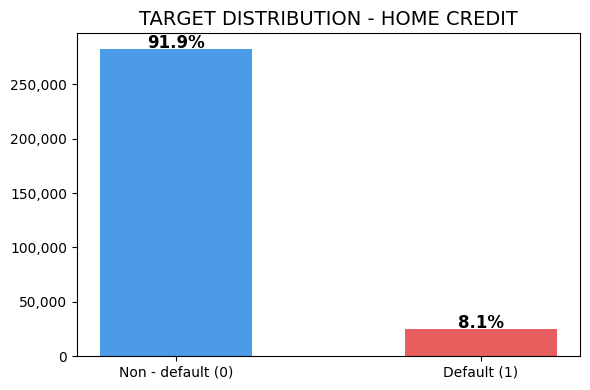

In [23]:
import matplotlib.pyplot as plt

target_counts = df['TARGET'].value_counts()
target_pct = df['TARGET'].value_counts(normalize=True).mul(100).round(1)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ['Non - default (0)', 'Default (1)'],
    target_counts.values,
    color=['#4C9BE8', '#E85D5D'],
    width=0.5
)

for bar, pct in zip(bars, target_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1000,
        f'{pct}%',
        ha='center', fontsize=12, fontweight='bold'
    )

ax.set_title('TARGET DISTRIBUTION - HOME CREDIT', fontsize=14)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## B3. FE

In [24]:
# ── Feature Engineering: tạo biến mới ─────────────────────────────

# 1. Tỉ lệ & ratio tài chính
df['CREDIT_INCOME_RATIO']     = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)
df['ANNUITY_INCOME_RATIO']    = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)
df['CREDIT_TERM']             = df['AMT_ANNUITY'] / (df['AMT_CREDIT'] + 1)
df['GOODS_CREDIT_RATIO']      = df['AMT_GOODS_PRICE'] / (df['AMT_CREDIT'] + 1)
df['INCOME_PER_PERSON']       = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + 1)
df['CHILDREN_RATIO']          = df['CNT_CHILDREN'] / (df['CNT_FAM_MEMBERS'] + 1)

# 2. Tuổi & thâm niên
df['AGE_YEARS']               = df['DAYS_BIRTH'] / -365
df['EMPLOYED_YEARS']          = df['DAYS_EMPLOYED'].clip(upper=0) / -365  # clip loại outlier 365243
df['EMPLOYED_TO_AGE_RATIO']   = df['EMPLOYED_YEARS'] / (df['AGE_YEARS'] + 1)
df['ID_PUBLISH_YEARS']        = df['DAYS_ID_PUBLISH'] / -365
df['REGISTRATION_YEARS']      = df['DAYS_REGISTRATION'] / -365
df['PHONE_CHANGE_YEARS']      = df['DAYS_LAST_PHONE_CHANGE'] / -365


# 3. Social circle risk
df['SOCIAL_DEF_RATE_30']      = df['DEF_30_CNT_SOCIAL_CIRCLE'] / (df['OBS_30_CNT_SOCIAL_CIRCLE'] + 1)
df['SOCIAL_DEF_RATE_60']      = df['DEF_60_CNT_SOCIAL_CIRCLE'] / (df['OBS_60_CNT_SOCIAL_CIRCLE'] + 1)

# 4. Credit bureau enquiries
df['AMT_REQ_CREDIT_TOTAL']    = (
    df['AMT_REQ_CREDIT_BUREAU_HOUR'] +
    df['AMT_REQ_CREDIT_BUREAU_DAY']  +
    df['AMT_REQ_CREDIT_BUREAU_WEEK'] +
    df['AMT_REQ_CREDIT_BUREAU_MON']  +
    df['AMT_REQ_CREDIT_BUREAU_QRT']  +
    df['AMT_REQ_CREDIT_BUREAU_YEAR']
)

# 5. Previous application features
df['PREV_CREDIT_DIFF']        = df['prev_amt_credit_mean'] - df['prev_amt_application_mean']
df['PREV_CREDIT_APP_RATIO']   = df['prev_amt_credit_mean'] / (df['prev_amt_application_mean'] + 1)

# thêm
df['PREV_APPROVAL_RATIO'] = df['prev_approved_count'] / (df['prev_count'] + 1)
df['PREV_REFUSED_RATIO']  = df['prev_refused_count']  / (df['prev_count'] + 1)


new_features = [
    'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM', 'GOODS_CREDIT_RATIO',
    'INCOME_PER_PERSON', 'CHILDREN_RATIO',
    'AGE_YEARS', 'EMPLOYED_YEARS', 'EMPLOYED_TO_AGE_RATIO',
    'ID_PUBLISH_YEARS', 'REGISTRATION_YEARS', 'PHONE_CHANGE_YEARS',
    'SOCIAL_DEF_RATE_30', 'SOCIAL_DEF_RATE_60',
    'AMT_REQ_CREDIT_TOTAL',
    'PREV_CREDIT_DIFF', 'PREV_CREDIT_APP_RATIO',
    'PREV_APPROVAL_RATIO', 'PREV_REFUSED_RATIO'

]

print(f"Đã tạo {len(new_features)} features mới")
print(f"Shape mới: {df.shape}")


Đã tạo 19 features mới
Shape mới: (307511, 149)


## B4. Split

In [25]:
HC_RAW_COLS = [c for c in df.columns if c != 'TARGET']

X_raw = df[HC_RAW_COLS].copy()
y     = df['TARGET'].copy()

# 60% train / 20% valid / 20% test
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_raw, y,
    test_size=0.4,
    stratify=y,
    random_state=RANDOM_SEED
)

X_valid_raw, X_test_raw, y_valid, y_test = train_test_split(
    X_temp_raw, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=RANDOM_SEED
)

# Alias dùng cho các bước sau (FE đã làm trước khi split ở B3)
X_train_fe = X_train_raw.copy()
X_valid_fe = X_valid_raw.copy()
X_test_fe  = X_test_raw.copy()

n_good = (y_train == 0).sum()
n_bad  = (y_train == 1).sum()
bad_w  = n_good / n_bad

print(f"Class weight: {bad_w:.2f}")
print(f"Train      : {X_train_fe.shape}")
print(f"Validation : {X_valid_fe.shape}")
print(f"Test       : {X_test_fe.shape}")

print("Bad rate")
print(f"Train      : {y_train.mean():.4f}")
print(f"Validation : {y_valid.mean():.4f}")
print(f"Test       : {y_test.mean():.4f}")


Class weight: 11.39
Train      : (184506, 148)
Validation : (61502, 148)
Test       : (61503, 148)
Bad rate
Train      : 0.0807
Validation : 0.0807
Test       : 0.0807


## B5. Preprocessing (impute → cap → WOE → scale)

In [26]:
## Cho tree-based

X_train_bl = X_train_fe.copy()
X_valid_bl = X_valid_fe.copy()
X_test_bl  = X_test_fe.copy()

# Impute toàn bộ numeric 
X_train_bl, X_valid_bl, X_test_bl = impute_all_numeric(
    X_train_bl, X_valid_bl, X_test_bl)

# Cap outliers (percentile lấy từ TRAIN)
X_train_bl, X_valid_bl, X_test_bl = cap_iqr(
    X_train_bl, X_valid_bl, X_test_bl)

# WOE + scale (fit trên TRAIN)
X_train_bl, X_valid_bl, X_test_bl, woe_hc, scaler_hc = apply_woe_scale(
    X_train_bl, X_valid_bl, X_test_bl, y_train)

print(f'Baseline input: train={X_train_bl.shape} | valid={X_valid_bl.shape} | test={X_test_bl.shape}')


  WOE cols=12 | drop=[] | shape train=(184506, 148)
Baseline input: train=(184506, 148) | valid=(61502, 148) | test=(61503, 148)


In [27]:
## cho TabNet

X_train_fe_prep = X_train_fe.copy()
X_valid_fe_prep = X_valid_fe.copy()
X_test_fe_prep  = X_test_fe.copy()

# ── v3: WOE cho cat + QT cho cont (6 giá trị trả về) ─────────────────────
# TabNet thư viện và grid 2x2 dùng CHUNG pipeline này -> so sánh hợp lệ.
X_train_tn, X_valid_tn, X_test_tn, qt_hc, woe_tn, N_CONT = preprocess_for_tabnet_v3(
    X_train_fe_prep, X_valid_fe_prep, X_test_fe_prep, y_train, max_card=20)

X_fe_tr_np = X_train_tn.values.astype(np.float32)
X_fe_va_np = X_valid_tn.values.astype(np.float32)
X_fe_te_np = X_test_tn.values.astype(np.float32)
FEAT_NAMES = list(X_train_tn.columns)

class_w_hc = np.where(y_train.values == 1, bad_w, 1.0)

print(f'\nTabNet input: {X_fe_tr_np.shape[1]} cột, PLR áp cho {N_CONT} cột')

  cont(+WOE)=107 | low_card=41 | shape train=(184506, 148)

TabNet input: 148 cột, PLR áp cho 107 cột


## B6. Baseline models

### 6.1. Tunning w Optuna

In [28]:
# N_TRIALS = 30

# TREE = {"XGBoost": objective_xgb, "LightGBM": objective_lgbm,
#         "CatBoost": objective_cat, "LogisticRegression": objective_lr}

# run_group(TREE, need=["X_train_bl", "X_valid_bl", "y_train", "y_valid", "bad_w"])

# run_group({"TabM": objective_tabm},
#           need=["X_fe_tr_np", "X_fe_va_np", "train_tabm_lib", "y_train", "y_valid", "bad_w"])

# run_group({"MLP": objective_mlp, "TabNet": objective_tabnet},
#           need=["X_fe_tr_np", "X_fe_va_np", "y_train", "y_valid", "bad_w"])

### 6.2. Applied Optuna

In [29]:
best = load_best_params(
    "/kaggle/input/datasets/phmththuvn/tunning-upload-1/best_params_baselines_T.json",
    "/kaggle/input/datasets/phmththuvn/tunning-upload-1/best_params_baselines_NN.json",
    "/kaggle/input/datasets/phmththuvn/tunning-upload-2/best_params_baselines_Proposed.json"
)

In [30]:
models = build_baseline_models(bad_w, best=best, n_samples=len(y_train))
results_hc = train_baseline_models(models, X_train_bl, X_valid_bl, X_test_bl,
                                   y_train, y_valid, y_test)
df_summary_hc = summarize_results(results_hc)
df_summary_hc

Training model  {'Logistic Regression'}
(2.7s)
  [valid] AUC=0.7676  Gini=0.5352  KS=0.4062  F1(bad)=0.2668
  [train] AUC=0.7700  Gini=0.5401  KS=0.4033  F1(bad)=0.2655
  [test] AUC=0.7730  Gini=0.5460  KS=0.4147  F1(bad)=0.2682
Training model  {'LightGBM'}
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1956]	valid_0's auc: 0.784606	valid_0's binary_logloss: 0.237504
(70.8s)
  [valid] AUC=0.7846  Gini=0.5692  KS=0.4314  F1(bad)=0.2827
  [train] AUC=0.8603  Gini=0.7206  KS=0.5568  F1(bad)=0.3225
  [test] AUC=0.7893  Gini=0.5786  KS=0.4409  F1(bad)=0.2854
Training model  {'XGBoost'}
(115.3s)
  [valid] AUC=0.7851  Gini=0.5703  KS=0.4325  F1(bad)=0.2943
  [train] AUC=0.8281  Gini=0.6561  KS=0.5020  F1(bad)=0.3206
  [test] AUC=0.7892  Gini=0.5784  KS=0.4420  F1(bad)=0.2982
Training model  {'CatBoost'}
(120.7s)
  [valid] AUC=0.7830  Gini=0.5660  KS=0.4282  F1(bad)=0.2852
  [train] AUC=0.8174  Gini=0.6348  KS=0.4819  F1(bad)=0.3035
  [test] A

,Model,Train AUC,Valid AUC,Test AUC,Valid KS,Test Gini,Test KS,Precision (Bad),Recall (Bad),Recall (Good),F1 (Bad),TP,FP,TN,FN,Threshold,Train Time (s)
0,XGBoost,0.8281,0.7851,0.7892,0.4325,0.5784,0.4420,0.1890,0.7063,0.7339,0.2982,3507,15047,41491,1458,0.0848,115.28
1,LightGBM,0.8603,0.7846,0.7893,0.4314,0.5786,0.4409,0.1767,0.7420,0.6963,0.2854,3684,17170,39368,1281,0.0744,70.81
2,CatBoost,0.8174,0.7830,0.7878,0.4282,0.5756,0.4338,0.1790,0.7212,0.7095,0.2868,3581,16423,40115,1384,0.0785,120.75
3,Logistic Regression,0.7700,0.7676,0.7730,0.4062,0.5460,0.4147,0.1637,0.7408,0.6677,0.2682,3678,18788,37750,1287,0.0736,2.74
4,MLP,0.7930,0.7554,0.7589,0.3820,0.5177,0.3877,0.1615,0.7122,0.6753,0.2633,3536,18358,38180,1429,0.0696,24.84


In [31]:
tn = best['TabNet']          # {'n_da', 'n_steps', 'gamma', 'lambda_sparse', 'lr'}

TABNET_INIT_CFG = dict(
    n_d=tn['n_da'], n_a=tn['n_da'],                 # ← map n_da sang n_d = n_a
    n_steps=tn['n_steps'],
    gamma=tn['gamma'],
    lambda_sparse=tn['lambda_sparse'],
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=tn['lr'], weight_decay=1e-5),
    seed=42, device_name='auto', verbose=0,
)
TABNET_FIT_CFG = dict(
    max_epochs=150, patience=20,
    batch_size=2048, virtual_batch_size=128,
    eval_metric=['auc'], weights=1,                 # weights=1 = cân bằng lớp
)

tabnet_hc_fe_default = TabNetClassifier(**TABNET_INIT_CFG)
t0 = time.time()
tabnet_hc_fe_default.fit(
    X_fe_tr_np, y_train.values.astype(np.int64),
    eval_set=[(X_fe_va_np, y_valid.values.astype(np.int64))],
    eval_name=['valid'], **TABNET_FIT_CFG)
tabnet_time = time.time() - t0

va = evaluate(tabnet_hc_fe_default, X_fe_va_np, y_valid.values.astype(np.int64), label='valid')
thr = va['threshold']
tr = evaluate(tabnet_hc_fe_default, X_fe_tr_np, y_train.values.astype(np.int64), label='train', threshold=thr)
te = evaluate(tabnet_hc_fe_default, X_fe_te_np, y_test.values.astype(np.int64),  label='test',  threshold=thr)
df_summary_hc = append_to_summary(df_summary_hc, 'TabNet', tr, va, te, train_time=round(tabnet_time, 2))
df_summary_hc


Early stopping occurred at epoch 42 with best_epoch = 22 and best_valid_auc = 0.77151
  [valid] AUC=0.7715  Gini=0.5430  KS=0.4122  F1(bad)=0.2770
  [train] AUC=0.7835  Gini=0.5671  KS=0.4316  F1(bad)=0.2838
  [test] AUC=0.7769  Gini=0.5539  KS=0.4186  F1(bad)=0.2784


,Model,Train AUC,Valid AUC,Test AUC,Valid KS,Test Gini,Test KS,Precision (Bad),Recall (Bad),Recall (Good),F1 (Bad),TP,FP,TN,FN,Threshold,Train Time (s)
0,XGBoost,0.8281,0.7851,0.7892,0.4325,0.5784,0.4420,0.1890,0.7063,0.7339,0.2982,3507,15047,41491,1458,0.0848,115.28
1,LightGBM,0.8603,0.7846,0.7893,0.4314,0.5786,0.4409,0.1767,0.7420,0.6963,0.2854,3684,17170,39368,1281,0.0744,70.81
2,CatBoost,0.8174,0.7830,0.7878,0.4282,0.5756,0.4338,0.1790,0.7212,0.7095,0.2868,3581,16423,40115,1384,0.0785,120.75
3,TabNet,0.7835,0.7715,0.7769,0.4122,0.5539,0.4186,0.1728,0.7160,0.6990,0.2784,3555,17020,39518,1410,0.4895,360.43
4,Logistic Regression,0.7700,0.7676,0.7730,0.4062,0.5460,0.4147,0.1637,0.7408,0.6677,0.2682,3678,18788,37750,1287,0.0736,2.74
5,MLP,0.7930,0.7554,0.7589,0.3820,0.5177,0.3877,0.1615,0.7122,0.6753,0.2633,3536,18358,38180,1429,0.0696,24.84


In [32]:
tm = best['TabM']          

w_tabm, tr, va, te, _, _, elapsed = train_tabm_lib(
    X_fe_tr_np, X_fe_va_np, X_fe_te_np,            
    y_train, y_valid, y_test, bad_w,
    seed=42, max_epochs=150, patience=20, warmup_epochs=5,
    verbose_every=1,                                
    **tm)                                          
df_summary_hc = append_to_summary(df_summary_hc, 'TabM', tr, va, te, train_time=round(elapsed, 2))
df_summary_hc

  [TabM] k=32 | d_block=384 | params=282,784
  [valid] AUC=0.7803  Gini=0.5606  KS=0.4195  F1(bad)=0.2847
  [train] AUC=0.8413  Gini=0.6827  KS=0.5234  F1(bad)=0.3224
  [test] AUC=0.7846  Gini=0.5692  KS=0.4275  F1(bad)=0.2871
  [TabM] Done 227.8s | Test AUC=0.7846


,Model,Train AUC,Valid AUC,Test AUC,Valid KS,Test Gini,Test KS,Precision (Bad),Recall (Bad),Recall (Good),F1 (Bad),TP,FP,TN,FN,Threshold,Train Time (s)
0,XGBoost,0.8281,0.7851,0.7892,0.4325,0.5784,0.4420,0.1890,0.7063,0.7339,0.2982,3507,15047,41491,1458,0.0848,115.28
1,LightGBM,0.8603,0.7846,0.7893,0.4314,0.5786,0.4409,0.1767,0.7420,0.6963,0.2854,3684,17170,39368,1281,0.0744,70.81
2,CatBoost,0.8174,0.7830,0.7878,0.4282,0.5756,0.4338,0.1790,0.7212,0.7095,0.2868,3581,16423,40115,1384,0.0785,120.75
3,TabM,0.8413,0.7803,0.7846,0.4195,0.5692,0.4275,0.1800,0.7096,0.7160,0.2871,3523,16054,40484,1442,0.4991,225.45
4,TabNet,0.7835,0.7715,0.7769,0.4122,0.5539,0.4186,0.1728,0.7160,0.6990,0.2784,3555,17020,39518,1410,0.4895,360.43
5,Logistic Regression,0.7700,0.7676,0.7730,0.4062,0.5460,0.4147,0.1637,0.7408,0.6677,0.2682,3678,18788,37750,1287,0.0736,2.74
6,MLP,0.7930,0.7554,0.7589,0.3820,0.5177,0.3877,0.1615,0.7122,0.6753,0.2633,3536,18358,38180,1429,0.0696,24.84


# C - PROPOSED

In [33]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from entmax import sparsemax


class BEWrapper:
    """Tương thích với evaluate() — predict_proba trả về xác suất trung bình."""
    def __init__(self, model, device, batch_size=2048):
        self.model, self.device, self.bs = model, device, batch_size

    def _forward(self, X):
        if hasattr(X, 'values'): X = X.values
        X = X.astype(np.float32)
        self.model.eval()
        out = []
        with torch.no_grad():
            for s in range(0, len(X), self.bs):
                xb = torch.tensor(X[s:s + self.bs]).to(self.device)
                lg, _ = self.model(xb)
                out.append(torch.sigmoid(lg).cpu().numpy())      # (b, k)
        return np.concatenate(out, axis=0)

    def predict_proba(self, X):
        p = self._forward(X).mean(axis=1)
        return np.column_stack([1 - p, p])

    def predict_with_uncertainty(self, X):
        """Trả về (PD trung bình, độ lệch chuẩn giữa k sub-model).
        std cao = các sub-model bất đồng = hồ sơ nên đẩy sang thẩm định thủ công."""
        P = self._forward(X)
        return P.mean(axis=1), P.std(axis=1)

class PLREmbeddings(nn.Module):
    def __init__(self, n_features, d_emb=8, n_frequencies=24, sigma=0.05):
        super().__init__()
        self.freqs = nn.Parameter(torch.randn(n_features, n_frequencies) * sigma)
        self.lin_w = nn.Parameter(torch.empty(n_features, 2 * n_frequencies, d_emb))
        self.lin_b = nn.Parameter(torch.zeros(n_features, d_emb))
        nn.init.uniform_(self.lin_w, -1.0 / math.sqrt(2 * n_frequencies),
                                      1.0 / math.sqrt(2 * n_frequencies))
        self.d_emb = d_emb

    def forward(self, x):                                              # (B, F)
        z = 2 * math.pi * self.freqs.unsqueeze(0) * x.unsqueeze(-1)
        z = torch.cat([torch.cos(z), torch.sin(z)], dim=-1)
        z = torch.einsum('bfk,fkd->bfd', z, self.lin_w) + self.lin_b
        return torch.relu(z)


class BELinear(nn.Module):
    def __init__(self, in_features, out_features, k=8, bias=True):
        super().__init__()
        self.k = k
        self.linear = nn.Linear(in_features, out_features, bias=False)
        self.r = nn.Parameter(torch.empty(k, in_features))
        self.s = nn.Parameter(torch.empty(k, out_features))
        self.b = nn.Parameter(torch.zeros(k, out_features)) if bias else None
        with torch.no_grad():
            self.r.copy_(torch.randint(0, 2, (k, in_features)).float() * 2 - 1)
            self.s.copy_(torch.randint(0, 2, (k, out_features)).float() * 2 - 1)

    def forward(self, x):                           # (B, k, in)
        out = self.linear(x * self.r) * self.s
        return out if self.b is None else out + self.b


class BE_BatchNorm(nn.Module):
    def __init__(self, dim, virtual_batch_size=128, momentum=0.02):
        super().__init__()
        self.bn  = nn.BatchNorm1d(dim, momentum=momentum)
        self.vbs = virtual_batch_size

    def forward(self, x):
        B, k, D = x.shape
        z = x.reshape(B * k, D)
        if self.training and self.vbs and z.shape[0] > self.vbs:
            n = max(1, z.shape[0] // self.vbs)
            z = torch.cat([self.bn(c) for c in z.chunk(n, dim=0)], dim=0)
        else:
            z = self.bn(z)
        return z.reshape(B, k, D)

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from entmax import sparsemax

# BEWrapper, PLREmbeddings, BELinear, BE_BatchNorm giữ y như file của bạn.
# Chỉ cần đảm bảo class TabNetBEPLR dưới đây là bản đang dùng:

class TabNetBEPLR(nn.Module):
    def __init__(self, n_features, k=8, use_plr=True, n_cont=None,
                 d_emb=8, n_frequencies=24, sigma=0.05,
                 n_d=64, n_a=None, n_steps=5, dropout=0.1, gamma=1.5):
        super().__init__()
        self.n_features, self.k, self.n_steps = n_features, k, n_steps
        self.n_d = n_d
        self.n_a = n_d if n_a is None else n_a          # chiều phần "chú ý" (a)
        self.gamma, self.use_plr = gamma, use_plr
        self.n_cont = n_features if n_cont is None else int(n_cont)
        out_dim = self.n_d + self.n_a

        self.bn_in = nn.BatchNorm1d(n_features)
        if use_plr:
            self.plr   = PLREmbeddings(self.n_cont, d_emb, n_frequencies, sigma)
            self.d_emb = d_emb
        else:
            self.plr   = None
            self.d_emb = 1
        flat_dim = n_features * self.d_emb

        self.shared_fc = nn.Sequential(
            BELinear(flat_dim, out_dim * 2, k), BE_BatchNorm(out_dim * 2), nn.GLU(dim=-1))
        self.step_fc = nn.ModuleList([
            nn.Sequential(BELinear(flat_dim, out_dim * 2, k), BE_BatchNorm(out_dim * 2), nn.GLU(dim=-1))
            for _ in range(n_steps)])

        self.attn_fc = nn.ModuleList([BELinear(self.n_a, n_features, k) for _ in range(n_steps)])
        self.attn_bn = nn.ModuleList([BE_BatchNorm(n_features) for _ in range(n_steps)])   # BN của TabNet gốc

        self.drop = nn.Dropout(dropout)
        self.head = BELinear(self.n_d, 1, k)

    def _embed(self, x):
        x = self.bn_in(x)
        if not self.use_plr:
            return x.unsqueeze(-1)
        if self.n_cont >= self.n_features:
            return self.plr(x)
        xc, xr = x[:, :self.n_cont], x[:, self.n_cont:]
        ec = self.plr(xc)
        er = xr.unsqueeze(-1).expand(-1, -1, self.d_emb)
        return torch.cat([ec, er], dim=1)

    def _encode(self, x, return_masks=False):
        B = x.size(0)
        E_k = self._embed(x).unsqueeze(1).expand(B, self.k, self.n_features, self.d_emb)
        E_flat = E_k.reshape(B, self.k, -1)

        init = self.shared_fc(E_flat)                            # (B,k,d+a)
        d0, a = torch.split(init, [self.n_d, self.n_a], dim=-1)  # SPLIT đầu -> a[0]

        prior = torch.ones(B, self.k, self.n_features, device=x.device)
        agg   = torch.zeros(B, self.k, self.n_d,      device=x.device)
        ent   = torch.zeros(1, device=x.device)
        masks = []
        for i in range(self.n_steps):
            scores = self.attn_bn[i](self.attn_fc[i](a))     # FC → BN
            mask   = sparsemax(scores * prior, dim=-1)        # ×prior TRƯỚC sparsemax
            if return_masks:
                masks.append(mask.detach())
            prior = prior * (self.gamma - mask)
            ent   = ent + (-mask * torch.log(mask + 1e-15)).sum(-1).mean()

            masked = (E_k * mask.unsqueeze(-1)).reshape(B, self.k, -1)
            ft     = self.step_fc[i](masked)
            d_i, a = torch.split(ft, [self.n_d, self.n_a], dim=-1)
            agg    = agg + self.drop(torch.relu(d_i))

        agg = agg / self.n_steps
        if return_masks:
            return agg, ent / self.n_steps, masks
        return agg, ent / self.n_steps

    def forward(self, x):
        agg, ent = self._encode(x)
        return self.head(agg).squeeze(-1), ent

    def get_masks(self, x):
        _, _, masks = self._encode(x, return_masks=True)
        return torch.stack(masks, dim=0)          # (steps, B, k, F)
        

In [34]:
def train_tabnet_be(
    X_train, X_valid, X_test, y_train, y_valid, y_test, bad_weight,
    k=8, use_plr=True, n_cont=None,
    d_emb=8, n_frequencies=24, sigma=0.05,
    n_d=64, n_steps=5, dropout=0.1, gamma=1.5,
    lambda_sparse=1e-4,
    lr=2e-3, weight_decay=1e-5, batch_size=512,
    max_epochs=150, patience=20, verbose_every=10,
    warmup_epochs=5, seed=42,
):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    torch.manual_seed(seed); np.random.seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

    def to_np(z, dt): return z.values.astype(dt) if hasattr(z, 'values') else np.array(z, dtype=dt)
    X_tr = torch.tensor(to_np(X_train, np.float32)); y_tr = torch.tensor(to_np(y_train, np.float32))
    X_va = torch.tensor(to_np(X_valid, np.float32)); y_va = torch.tensor(to_np(y_valid, np.float32))

    crit = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([bad_weight]).to(device))

    train_dl = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size,
                          shuffle=True, pin_memory=True, drop_last=True)
    valid_dl = DataLoader(TensorDataset(X_va, y_va), batch_size=2048, shuffle=False)

    model = TabNetBEPLR(
        X_tr.shape[1], k=k, use_plr=use_plr, n_cont=n_cont,
        d_emb=d_emb, n_frequencies=n_frequencies, sigma=sigma,
        n_d=n_d, n_steps=n_steps, dropout=dropout, gamma=gamma).to(device)

    if verbose_every < 1000:
        n_par = sum(p.numel() for p in model.parameters())
        print(f'  k={k} | PLR={use_plr} | n_cont={model.n_cont}/{X_tr.shape[1]} | params={n_par:,}')

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    if warmup_epochs > 0:
        sch = SequentialLR(opt, schedulers=[
            LinearLR(opt, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs),
            CosineAnnealingLR(opt, T_max=max_epochs - warmup_epochs, eta_min=1e-6)],
            milestones=[warmup_epochs])
    else:
        sch = CosineAnnealingLR(opt, T_max=max_epochs, eta_min=1e-6)

    best_auc, best_state, no_imp, history = 0.0, None, 0, []
    t0 = time.time()
    for epoch in range(max_epochs):
        model.train()
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            lg, ent = model(xb)                           # (B, k)
            yk = yb.unsqueeze(1).expand_as(lg)            # mọi thành viên học cùng target
            (crit(lg, yk) + lambda_sparse * ent).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sch.step()

        model.eval(); ps, ls = [], []
        with torch.no_grad():
            for xb, yb in valid_dl:
                lg, _ = model(xb.to(device))
                ps.append(torch.sigmoid(lg).mean(dim=1).cpu()); ls.append(yb)
        auc = roc_auc_score(torch.cat(ls).numpy(), torch.cat(ps).numpy())
        history.append(auc)

        if (epoch + 1) % verbose_every == 0 or epoch == 0:
            print(f'    Epoch {epoch+1:3d} | valid_auc={auc:.5f} | {time.time()-t0:.0f}s')
        if auc > best_auc + 1e-5:
            best_auc, no_imp = auc, 0
            best_state = {kk: v.cpu().clone() for kk, v in model.state_dict().items()}
        else:
            no_imp += 1
            if no_imp >= patience:
                if verbose_every < 1000:
                    print(f'    Early stop @ epoch {epoch+1} | best_valid={best_auc:.5f}')
                break

    model.load_state_dict(best_state); model.to(device)
    wrapper = BEWrapper(model, device)

    va_m = evaluate(wrapper, to_np(X_valid, np.float32), to_np(y_valid, np.int64), label='valid')
    thr  = va_m['threshold']
    tr_m = evaluate(wrapper, to_np(X_train, np.float32), to_np(y_train, np.int64),
                    label='train', threshold=thr)
    te_m = evaluate(wrapper, to_np(X_test, np.float32), to_np(y_test, np.int64),
                    label='test', threshold=thr)
    print(f'  Done {time.time()-t0:.1f}s | Train={tr_m["auc"]:.4f} | '
          f'Valid={va_m["auc"]:.4f} | Test={te_m["auc"]:.4f} | '
          f'Gap={tr_m["auc"]-va_m["auc"]:.4f}')
    return wrapper, tr_m, va_m, te_m, history, model, device

In [35]:
TUNE_SEED = 42
N_TRIALS  = 30


BASE_CFG = dict(
    n_cont=N_CONT,
    d_emb=8, n_frequencies=24, sigma=0.05,
    n_d=64, n_steps=4, dropout=0.1, gamma=1.3,
    lambda_sparse=1e-4,
    lr=1e-3,
    weight_decay=1e-5,
    batch_size=512,
    max_epochs=40,
    patience=10,
    warmup_epochs=2,
    seed=42,
)

In [36]:
# import optuna
# optuna.logging.set_verbosity(optuna.logging.WARNING)

# # 6 tham số Optuna sẽ dò. Mọi thứ khác giữ đúng BASE_CFG.
# SEARCH_KEYS = ['n_d', 'n_steps', 'gamma', 'lambda_sparse', 'lr', 'dropout']

# def objective_prop(trial):
#     searched = dict(
#         n_d           = trial.suggest_int("n_d", 32, 96, step=16),
#         n_steps       = trial.suggest_int("n_steps", 3, 7),
#         gamma         = trial.suggest_float("gamma", 1.0, 2.0),
#         lambda_sparse = trial.suggest_float("lambda_sparse", 1e-5, 1e-2, log=True),
#         lr            = trial.suggest_float("lr", 5e-4, 5e-3, log=True),
#         dropout       = trial.suggest_float("dropout", 0.0, 0.3),
#     )
#     # Lấy nền từ BASE_CFG, bỏ 6 tham số đang dò và bỏ seed (dùng TUNE_SEED)
#     base = {kk: v for kk, v in BASE_CFG.items()
#             if kk not in SEARCH_KEYS and kk != 'seed'}

#     _, _, va_m, *_ = train_tabnet_be(
#         X_fe_tr_np, X_fe_va_np, X_fe_va_np,     # X_test = valid -> KHÔNG đụng test
#         y_train, y_valid, y_valid, bad_w,
#         k=8, use_plr=True, seed=TUNE_SEED,      # k & PLR khóa cứng
#         verbose_every=10**9,
#         **base, **searched)
#     return va_m['auc']

# study_prop = optuna.create_study(
#     direction="maximize",
#     sampler=optuna.samplers.TPESampler(seed=TUNE_SEED))
# study_prop.optimize(objective_prop, n_trials=N_TRIALS, show_progress_bar=True)

# print("Best valid AUC:", round(study_prop.best_value, 4))
# print("Best params   :", study_prop.best_params)

In [37]:
# tm = best['Proposed']          

# w_tabm, tr, va, te, _, _, elapsed = train_tabm_lib(
#     X_fe_tr_np, X_fe_va_np, X_fe_te_np,            
#     y_train, y_valid, y_test, bad_w,
#     seed=42, max_epochs=150, patience=20, warmup_epochs=5,
#     verbose_every=1,                                
#     **tm)                                          
# df_summary_hc = append_to_summary(df_summary_hc, 'TabM', tr, va, te, train_time=round(elapsed, 2))
# df_summary_hc

In [38]:
tm = best['Proposed']      # chú ý: có ['params'] vì JSON lồng 1 tầng

# Nền BASE_CFG (bỏ seed vì truyền tay), rồi đè 6 tham số tune lên
final_cfg = {kk: v for kk, v in BASE_CFG.items() if kk != 'seed'}
final_cfg.update(tm)

# Kiểm tra trước khi train
assert final_cfg.get('n_cont') is not None, "Thiếu n_cont -> PLR áp sai!"
print("n_cont:", final_cfg['n_cont'],
      "| d_emb:", final_cfg['d_emb'],
      "| batch_size:", final_cfg['batch_size'],
      "| max_epochs:", final_cfg['max_epochs'])
print("6 tham số tune:", tm)

# wrap, tr_m, va_m, te_m, hist, raw, dev = train_tabnet_be(
#     X_fe_tr_np, X_fe_va_np, X_fe_te_np,
#     y_train, y_valid, y_test, bad_w,
#     k=8, use_plr=True, seed=42,
#     verbose_every=10, **final_cfg)

# print("TEST AUC:", round(te_m['auc'], 4))

n_cont: 107 | d_emb: 8 | batch_size: 512 | max_epochs: 40
6 tham số tune: {'n_d': 32, 'n_steps': 6, 'gamma': 1.472520062066199, 'lambda_sparse': 0.00014508855366255824, 'lr': 0.0014350621441156332, 'dropout': 0.19270861684184856}


## Quét k và d_emb (chọn trên valid, chưa đụng test)

In [39]:
# import pandas as pd

# best6 = best['Proposed']      

# K_GRID    = [1, 4, 8, 16]                 # số mô hình ensemble (k=1 = tắt ensemble)
# DEMB_GRID = [4, 8, 16]                    # số chiều embedding PLR

# # Nền = BASE_CFG, bỏ: seed (truyền tay), d_emb (sẽ quét), 6 tham số đã tune
# base = {kk: v for kk, v in BASE_CFG.items()
#         if kk not in best6 and kk not in ('seed', 'd_emb')}

# # Kiểm tra nhanh: n_cont phải còn, không được None
# assert base.get('n_cont') is not None, "Thiếu n_cont -> PLR áp sai!"

# records = []
# for k in K_GRID:
#     for d_emb in DEMB_GRID:
#         _, tr_m, va_m, *_ = train_tabnet_be(
#             X_fe_tr_np, X_fe_va_np, X_fe_va_np,     # test = valid -> CHƯA đụng test
#             y_train, y_valid, y_valid, bad_w,
#             k=k, use_plr=True, d_emb=d_emb, seed=TUNE_SEED,
#             verbose_every=10**9,
#             **base, **best6)
#         records.append((k, d_emb, va_m['auc']))
#         print(f"k={k:2d}  d_emb={d_emb:2d}  valid AUC={va_m['auc']:.4f}")

# df_sweep = (pd.DataFrame(records, columns=['k', 'd_emb', 'valid_auc'])
#               .sort_values('valid_auc', ascending=False)
#               .reset_index(drop=True))
# df_sweep

## Cell B — Train lại model cuối bằng best6 + (k, d_emb) tốt nhất, rồi mới đo test

In [40]:
# best_row  = df_sweep.iloc[0]              # hàng valid AUC cao nhất
# best_k    = int(best_row['k'])
# best_demb = int(best_row['d_emb'])
# print("Chọn cuối:  k =", best_k, "| d_emb =", best_demb)

# # Nền = BASE_CFG (bỏ seed, bỏ d_emb), đè 6 tham số tune, rồi đè d_emb đã chọn
# final_cfg = {kk: v for kk, v in BASE_CFG.items() if kk not in ('seed', 'd_emb')}
# final_cfg.update(best6)
# final_cfg['d_emb'] = best_demb

# assert final_cfg.get('n_cont') is not None, "Thiếu n_cont -> PLR áp sai!"
# print("n_cont:", final_cfg['n_cont'], "| d_emb:", final_cfg['d_emb'],
#       "| max_epochs:", final_cfg['max_epochs'])

# wrap, tr_m, va_m, te_m, hist, raw, dev = train_tabnet_be(
#     X_fe_tr_np, X_fe_va_np, X_fe_te_np,   # lần này dùng test THẬT
#     y_train, y_valid, y_test, bad_w,
#     k=best_k, use_plr=True, seed=42,
#     verbose_every=10, **final_cfg)

# print("VALID AUC:", round(va_m['auc'], 4))
# print("TEST  AUC:", round(te_m['auc'], 4))

## grid search đầy đủ: chọn cấu hình PLR có Valid AUC tốt nhất trên toàn bộ các tổ hợp sigma × d_emb × n_freq

In [41]:
# import time
# import pandas as pd

# FIXED_CFG = dict(
#     n_cont=N_CONT,
#     n_d=64, n_steps=5, dropout=0.1, gamma=1.5,
#     lambda_sparse=1e-4, lr=2e-3, weight_decay=1e-5,
#     batch_size=512, max_epochs=150, patience=20, warmup_epochs=5,
#     verbose_every=1000,        # ← tắt log mỗi epoch cho gọn
# )
# K_FIXED = 8
# SEED    = 42


# def run_one(d_emb, n_frequencies, sigma):
#     t0 = time.time()
#     _, tr_m, va_m, te_m, *_ = train_tabnet_be(
#         X_fe_tr_np, X_fe_va_np, X_fe_te_np,
#         y_train, y_valid, y_test, bad_w,
#         k=K_FIXED, use_plr=True, seed=SEED,
#         d_emb=d_emb, n_frequencies=n_frequencies, sigma=sigma,
#         **FIXED_CFG)
#     return dict(
#         d_emb=d_emb, n_freq=n_frequencies, sigma=sigma,
#         valid_auc=round(va_m['auc'], 4),
#         test_auc=round(te_m['auc'], 4),
#         gap=round(tr_m['auc'] - va_m['auc'], 4),
#         time_s=round(time.time() - t0, 1),
#     )


# def tune_plr():
#     results = []

#     print("=== GRID SEARCH PLR | k=8 ===")

#     for sg in [0.01, 0.05, 0.1, 1.0, 10.0]:
#         for de in [8, 16, 32]:
#             for nf in [24, 48]:

#                 r = run_one(
#                     d_emb=de,
#                     n_frequencies=nf,
#                     sigma=sg
#                 )
#                 results.append(r)

#                 print(
#                     f"sigma={sg:<5} | "
#                     f"d_emb={de:<3} | "
#                     f"n_freq={nf:<3} | "
#                     f"valid={r['valid_auc']} | "
#                     f"test={r['test_auc']} | "
#                     f"gap={r['gap']} | "
#                     f"{r['time_s']}s"
#                 )

#     # Tất cả kết quả, xếp theo Valid AUC
#     df = (
#         pd.DataFrame(results)
#         .drop_duplicates(
#             subset=['d_emb', 'n_freq', 'sigma']
#         )
#         .sort_values(
#             'valid_auc',
#             ascending=False
#         )
#         .reset_index(drop=True)
#     )

#     # Chọn BEST theo VALID AUC
#     best = df.iloc[0]

#     print("\n=== BEST PLR (theo Valid AUC) ===")
#     print(
#         f"d_emb={int(best['d_emb'])}, "
#         f"n_freq={int(best['n_freq'])}, "
#         f"sigma={best['sigma']}"
#     )
#     print(
#         f"valid={best['valid_auc']} | "
#         f"test={best['test_auc']} | "
#         f"gap={best['gap']}"
#     )

#     return df

# df_plr = tune_plr()
# df_plr

# df_plr.to_excel('PLR_embedding_gridsearch.xlsx')

In [42]:
best_k, best_demb = 8, 8

final_cfg = {kk: v for kk, v in BASE_CFG.items() if kk not in ('seed', 'd_emb')}
final_cfg.update(best['Proposed'])
final_cfg['d_emb'] = best_demb

wrap, tr_m, va_m, te_m, hist, raw, dev = train_tabnet_be(
    X_fe_tr_np, X_fe_va_np, X_fe_te_np,
    y_train, y_valid, y_test, bad_w,
    k=best_k, use_plr=True, seed=42,
    verbose_every=10, **final_cfg)

print("VALID AUC:", round(va_m['auc'], 4))
print("TEST  AUC:", round(te_m['auc'], 4))

  k=8 | PLR=True | n_cont=107/148 | params=1,234,344
    Epoch   1 | valid_auc=0.64052 | 26s
    Epoch  10 | valid_auc=0.77617 | 261s
    Epoch  20 | valid_auc=0.78121 | 522s
    Epoch  30 | valid_auc=0.78184 | 783s
    Early stop @ epoch 33 | best_valid=0.78350
  [valid] AUC=0.7835  Gini=0.5670  KS=0.4257  F1(bad)=0.2936
  [train] AUC=0.8136  Gini=0.6271  KS=0.4780  F1(bad)=0.3133
  [test] AUC=0.7866  Gini=0.5733  KS=0.4372  F1(bad)=0.2965
  Done 869.4s | Train=0.8136 | Valid=0.7835 | Test=0.7866 | Gap=0.0301
VALID AUC: 0.7835
TEST  AUC: 0.7866


In [43]:
df_summary_hc = append_to_summary(
    df_summary_hc,
    'ImpTabNet (k=8, PLR d=8, tuned)',   # tên model — đặt sao cho phân biệt được
    tr_m, va_m, te_m,
    train_time=round(sum(hist), 2)        # tổng thời gian; nếu hist không phải list thời gian thì bỏ dòng này
)
df_summary_hc

,Model,Train AUC,Valid AUC,Test AUC,Valid KS,Test Gini,Test KS,Precision (Bad),Recall (Bad),Recall (Good),F1 (Bad),TP,FP,TN,FN,Threshold,Train Time (s)
0,XGBoost,0.8281,0.7851,0.7892,0.4325,0.5784,0.4420,0.1890,0.7063,0.7339,0.2982,3507,15047,41491,1458,0.0848,115.28
1,LightGBM,0.8603,0.7846,0.7893,0.4314,0.5786,0.4409,0.1767,0.7420,0.6963,0.2854,3684,17170,39368,1281,0.0744,70.81
2,"ImpTabNet (k=8, PLR d=8, tuned)",0.8136,0.7835,0.7866,0.4257,0.5733,0.4372,0.1886,0.6920,0.7386,0.2965,3436,14778,41760,1529,0.5220,25.53
3,CatBoost,0.8174,0.7830,0.7878,0.4282,0.5756,0.4338,0.1790,0.7212,0.7095,0.2868,3581,16423,40115,1384,0.0785,120.75
4,TabM,0.8413,0.7803,0.7846,0.4195,0.5692,0.4275,0.1800,0.7096,0.7160,0.2871,3523,16054,40484,1442,0.4991,225.45
5,TabNet,0.7835,0.7715,0.7769,0.4122,0.5539,0.4186,0.1728,0.7160,0.6990,0.2784,3555,17020,39518,1410,0.4895,360.43
6,Logistic Regression,0.7700,0.7676,0.7730,0.4062,0.5460,0.4147,0.1637,0.7408,0.6677,0.2682,3678,18788,37750,1287,0.0736,2.74
7,MLP,0.7930,0.7554,0.7589,0.3820,0.5177,0.3877,0.1615,0.7122,0.6753,0.2633,3536,18358,38180,1429,0.0696,24.84


# D - MULTI SEED

## D1 - For proposed

In [44]:
def agg_seeds(name, aucs, ginis=None, kss=None, times=None):
    """Gộp list kết quả nhiều seed -> 1 dòng mean ± std."""
    row = {'Model': name,
           'Test AUC (mean)':  round(np.mean(aucs), 4),
           'Test AUC (std)':   round(np.std(aucs),  4),
           'n_seeds': len(aucs)}
    if ginis is not None: row['Test Gini (mean)'] = round(np.mean(ginis), 4)
    if kss  is not None:  row['Test KS (mean)']   = round(np.mean(kss),   4)
    if times is not None: row['Time (mean s)']    = round(np.mean(times), 1)
    return row

SEEDS = [42, 1, 7]        
seed_rows = []
prob_test_all = {s: {} for s in SEEDS}   # proba test của MỌI model tại MỌI seed -> Phần F (DeLong per-seed)
prob_test_s42 = prob_test_all[42]         # alias: seed 42 (Table IV) -> code cũ vẫn chạy

# final_cfg đã dựng ở bước trước: BASE_CFG (bỏ seed, d_emb) + best6 + d_emb=8
aucs, ginis, kss, times = [], [], [], []
for s in SEEDS:
    t0 = time.time()
    wrap_s, _, va_m, te_m, *_ = train_tabnet_be(
        X_fe_tr_np, X_fe_va_np, X_fe_te_np,
        y_train, y_valid, y_test, bad_w,
        k=8, use_plr=True, seed=s,
        verbose_every=10**9, **final_cfg)
    times.append(time.time() - t0)
    aucs.append(te_m['auc']); ginis.append(te_m['gini']); kss.append(te_m['ks'])
    print(f"[Proposed] seed={s}: test AUC={te_m['auc']:.4f}")
    prob_test_all[s]['Proposed'] = wrap_s.predict_proba(X_fe_te_np)[:, 1]

seed_rows.append(agg_seeds('ImpTabNet (k=8, PLR d=8, tuned)', aucs, ginis, kss, times))
print(f"  -> {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")

    Epoch   1 | valid_auc=0.64052 | 26s
  [valid] AUC=0.7835  Gini=0.5670  KS=0.4257  F1(bad)=0.2936
  [train] AUC=0.8136  Gini=0.6271  KS=0.4780  F1(bad)=0.3133
  [test] AUC=0.7866  Gini=0.5733  KS=0.4372  F1(bad)=0.2965
  Done 868.9s | Train=0.8136 | Valid=0.7835 | Test=0.7866 | Gap=0.0301
[Proposed] seed=42: test AUC=0.7866
    Epoch   1 | valid_auc=0.65875 | 26s
  [valid] AUC=0.7817  Gini=0.5635  KS=0.4278  F1(bad)=0.2874
  [train] AUC=0.8162  Gini=0.6324  KS=0.4826  F1(bad)=0.3070
  [test] AUC=0.7858  Gini=0.5715  KS=0.4362  F1(bad)=0.2912
  Done 998.6s | Train=0.8162 | Valid=0.7817 | Test=0.7858 | Gap=0.0345
[Proposed] seed=1: test AUC=0.7858
    Epoch   1 | valid_auc=0.64462 | 26s
  [valid] AUC=0.7819  Gini=0.5638  KS=0.4268  F1(bad)=0.2757
  [train] AUC=0.8108  Gini=0.6216  KS=0.4730  F1(bad)=0.2899
  [test] AUC=0.7873  Gini=0.5746  KS=0.4355  F1(bad)=0.2785
  Done 822.0s | Train=0.8108 | Valid=0.7819 | Test=0.7873 | Gap=0.0289
[Proposed] seed=7: test AUC=0.7873
  -> 0.7866 ± 0

## D2 - FOR BASELINE (Logistic Regression, LightGBM, XGBoost, CatBoost, MLP)

In [45]:
print("Các key trong best:", list(best.keys()))
print()
for name in ['XGBoost', 'LightGBM', 'CatBoost']:   # sửa tên nếu key khác
    if name in best:
        print(f"[{name}] param đã tune:")
        print("  ", best[name])
        print()
    else:
        print(f"[{name}] KHÔNG có trong best -> key sai tên\n")

Các key trong best: ['XGBoost', 'LightGBM', 'CatBoost', 'LogisticRegression', 'TabM', 'MLP', 'TabNet', 'Proposed']

[XGBoost] param đã tune:
   {'learning_rate': 0.028180680291847244, 'max_depth': 3, 'min_child_weight': 14.00042750373098, 'subsample': 0.7760609974958406, 'colsample_bytree': 0.6488152939379115, 'reg_lambda': 0.09565499215943825}

[LightGBM] param đã tune:
   {'scale_pos_weight': 1.0, 'learning_rate': 0.018020684901970098, 'num_leaves': 17, 'min_child_samples': 161, 'subsample': 0.8359581064679306, 'colsample_bytree': 0.8801151332999179, 'reg_lambda': 3.640392501061493}

[CatBoost] param đã tune:
   {'learning_rate': 0.024024430499735266, 'depth': 4, 'l2_leaf_reg': 5.946851656967488, 'random_strength': 0.3007016232607128}



In [46]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

def build_baseline(name, seed):
    p = dict(best.get(name, {}))
    p.pop('random_state', None); p.pop('random_seed', None); p.pop('seed', None)

    if name == 'XGBoost':
        return XGBClassifier(
            n_estimators=3000, tree_method="hist", eval_metric='auc',
            early_stopping_rounds=50, random_state=seed, n_jobs=-1,
            **p)                                   # KHÔNG thêm scale_pos_weight
    if name == 'LightGBM':
        return LGBMClassifier(
            n_estimators=3000, subsample_freq=1,
            random_state=seed, n_jobs=-1, verbose=-1,
            **p)                                   # scale_pos_weight=1.0 đã nằm trong p
    if name == 'CatBoost':
        return CatBoostClassifier(
            iterations=3000, eval_metric="AUC",
            random_seed=seed, verbose=0,
            **p)                                   # CatBoost gốc cũng KHÔNG thêm scale_pos_weight
    if name == 'Logistic Regression':
        return LogisticRegression(
            random_state=seed, max_iter=3000, solver="lbfgs",
            **p)
    if name == 'MLP':
        return MLPClassifier(
            solver='adam', max_iter=200, early_stopping=True,
            validation_fraction=0.15, n_iter_no_change=15, random_state=seed,
            **_mlp_params(best.get('MLP', {})))

def fit_baseline(name, model):
    if name == 'XGBoost':
        model.fit(X_fe_tr_np, y_train, eval_set=[(X_fe_va_np, y_valid)], verbose=False)
    elif name == 'LightGBM':
        model.fit(X_fe_tr_np, y_train, eval_set=[(X_fe_va_np, y_valid)],
                  eval_metric='auc', callbacks=[early_stopping(100), log_evaluation(0)])
    elif name == 'CatBoost':
        model.fit(X_fe_tr_np, y_train, eval_set=(X_fe_va_np, y_valid),
                  early_stopping_rounds=50, verbose=False)
    else:  # Logistic Regression, MLP -> fit thường, không cần eval_set
        model.fit(X_fe_tr_np, y_train)
    return model

BASELINE_NAMES = ['Logistic Regression', 'LightGBM', 'XGBoost', 'CatBoost', 'MLP']

for name in BASELINE_NAMES:
    aucs, ginis, kss, times = [], [], [], []
    for s in SEEDS:
        t0 = time.time()
        m = fit_baseline(name, build_baseline(name, s))
        times.append(time.time() - t0)
        va = evaluate(m, X_fe_va_np, y_valid)
        te = evaluate(m, X_fe_te_np, y_test, threshold=va['threshold'])
        aucs.append(te['auc']); ginis.append(te['gini']); kss.append(te['ks'])
        print(f"[{name}] seed={s}: test AUC={te['auc']:.4f}")
        prob_test_all[s][name] = m.predict_proba(X_fe_te_np)[:, 1]
    seed_rows.append(agg_seeds(name, aucs, ginis, kss, times))
    print(f"  -> {np.mean(aucs):.4f} ± {np.std(aucs):.4f}\n")

[Logistic Regression] seed=42: test AUC=0.7724
[Logistic Regression] seed=1: test AUC=0.7724
[Logistic Regression] seed=7: test AUC=0.7724
  -> 0.7724 ± 0.0000

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1857]	valid_0's auc: 0.785915	valid_0's binary_logloss: 0.236883
[LightGBM] seed=42: test AUC=0.7905
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2374]	valid_0's auc: 0.786638	valid_0's binary_logloss: 0.236657
[LightGBM] seed=1: test AUC=0.7902
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2539]	valid_0's auc: 0.786882	valid_0's binary_logloss: 0.236659
[LightGBM] seed=7: test AUC=0.7905
  -> 0.7904 ± 0.0002

[XGBoost] seed=42: test AUC=0.7900
[XGBoost] seed=1: test AUC=0.7892
[XGBoost] seed=7: test AUC=0.7895
  -> 0.7896 ± 0.0003

[CatBoost] seed=42: test AUC=0.7872
[CatBoost] seed=1: test AUC=0.7871
[CatBoost] seed=7: test AU

## D3 - FOR TABNET (baseline, thư viện pytorch-tabnet)

In [47]:
from pytorch_tabnet.tab_model import TabNetClassifier

aucs, ginis, kss, times = [], [], [], []
for s in SEEDS:
    t0 = time.time()
    cfg = dict(TABNET_INIT_CFG)
    cfg['seed'] = s
    m = TabNetClassifier(**cfg)
    m.fit(X_fe_tr_np, y_train.values.astype(np.int64),
          eval_set=[(X_fe_va_np, y_valid.values.astype(np.int64))],
          eval_name=['valid'], **TABNET_FIT_CFG)
    times.append(time.time() - t0)
    va = evaluate(m, X_fe_va_np, y_valid.values.astype(np.int64))
    te = evaluate(m, X_fe_te_np, y_test.values.astype(np.int64), threshold=va['threshold'])
    aucs.append(te['auc']); ginis.append(te['gini']); kss.append(te['ks'])
    print(f"[TabNet] seed={s}: test AUC={te['auc']:.4f}")
    prob_test_all[s]['TabNet'] = m.predict_proba(X_fe_te_np)[:, 1]

seed_rows.append(agg_seeds('TabNet', aucs, ginis, kss, times))
print(f"  -> {np.mean(aucs):.4f} ± {np.std(aucs):.4f}\n")


Early stopping occurred at epoch 42 with best_epoch = 22 and best_valid_auc = 0.77151
[TabNet] seed=42: test AUC=0.7769

Early stopping occurred at epoch 42 with best_epoch = 22 and best_valid_auc = 0.76467
[TabNet] seed=1: test AUC=0.7712

Early stopping occurred at epoch 50 with best_epoch = 30 and best_valid_auc = 0.76981
[TabNet] seed=7: test AUC=0.7697
  -> 0.7726 ± 0.0031



## D4 - FOR TABM (baseline, thư viện tabm)

In [48]:
tm = best['TabM']

aucs, ginis, kss, times = [], [], [], []
for s in SEEDS:
    t0 = time.time()
    w_tabm_s, tr_s, va_s, te_s, _, _, elapsed = train_tabm_lib(
        X_fe_tr_np, X_fe_va_np, X_fe_te_np,
        y_train, y_valid, y_test, bad_w,
        seed=s, max_epochs=150, patience=20, warmup_epochs=5,
        verbose_every=10**9,
        **tm)
    times.append(time.time() - t0)
    aucs.append(te_s['auc']); ginis.append(te_s['gini']); kss.append(te_s['ks'])
    print(f"[TabM] seed={s}: test AUC={te_s['auc']:.4f}")
    prob_test_all[s]['TabM'] = w_tabm_s.predict_proba(X_fe_te_np)[:, 1]

seed_rows.append(agg_seeds('TabM', aucs, ginis, kss, times))
print(f"  -> {np.mean(aucs):.4f} ± {np.std(aucs):.4f}\n")

  [valid] AUC=0.7803  Gini=0.5606  KS=0.4195  F1(bad)=0.2847
  [train] AUC=0.8413  Gini=0.6827  KS=0.5234  F1(bad)=0.3224
  [test] AUC=0.7846  Gini=0.5692  KS=0.4275  F1(bad)=0.2871
  [TabM] Done 228.1s | Test AUC=0.7846
[TabM] seed=42: test AUC=0.7846
  [valid] AUC=0.7801  Gini=0.5603  KS=0.4216  F1(bad)=0.2832
  [train] AUC=0.8545  Gini=0.7091  KS=0.5492  F1(bad)=0.3285
  [test] AUC=0.7837  Gini=0.5673  KS=0.4262  F1(bad)=0.2851
  [TabM] Done 266.3s | Test AUC=0.7837
[TabM] seed=1: test AUC=0.7837
  [valid] AUC=0.7805  Gini=0.5609  KS=0.4236  F1(bad)=0.2790
  [train] AUC=0.8354  Gini=0.6708  KS=0.5132  F1(bad)=0.3094
  [test] AUC=0.7840  Gini=0.5679  KS=0.4293  F1(bad)=0.2805
  [TabM] Done 212.5s | Test AUC=0.7840
[TabM] seed=7: test AUC=0.7840
  -> 0.7841 ± 0.0004



## D5 - TỔNG HỢP TẤT CẢ MODEL (multi-seed)

In [49]:
df_multiseed_all = (pd.DataFrame(seed_rows)
                     .sort_values('Test AUC (mean)', ascending=False)
                     .reset_index(drop=True))
df_multiseed_all

# Lưu proba test (mọi model, mọi seed) -> lần sau chỉ cần load, không train lại
import pickle
with open('prob_test_all.pkl', 'wb') as f:
    pickle.dump({'prob_test_all': prob_test_all, 'y_test': np.asarray(y_test)}, f)
print('Đã lưu prob_test_all.pkl')

Đã lưu prob_test_all.pkl


# E - ABLATION

In [50]:
import time, pandas as pd

best6     = best['Proposed']
best_demb = 8

base = {kk: v for kk, v in BASE_CFG.items() if kk not in ('seed', 'd_emb')}
base.update(best6)

grid = [
    dict(name='Base TabNet',                    k=1, use_plr=False, d_emb=None),
    dict(name='TabNet + PLR',                   k=1, use_plr=True,  d_emb=best_demb),
    dict(name='TabNet + BatchEnsemble',         k=8, use_plr=False, d_emb=None),
    dict(name='Proposed (PLR + BatchEnsemble)', k=8, use_plr=True,  d_emb=best_demb),
]

# Khởi tạo bảng RỖNG nhưng CÓ SẴN các cột -> tránh KeyError 'Model'
ABL_COLS = ['Model','Train AUC','Valid AUC','Test AUC','Valid KS','Test Gini','Test KS',
            'Precision (Bad)','Recall (Bad)','Recall (Good)','F1 (Bad)',
            'TP','FP','TN','FN','Threshold','Train Time (s)']
df_ablation = pd.DataFrame(columns=ABL_COLS)

for cfg in grid:
    print(f"\n=== {cfg['name']} ===")
    t0 = time.time()
    kwargs = dict(base)
    if cfg['use_plr']:
        kwargs['d_emb'] = cfg['d_emb']
    wrap, tr_m, va_m, te_m, hist, raw, dev = train_tabnet_be(
        X_fe_tr_np, X_fe_va_np, X_fe_te_np,
        y_train, y_valid, y_test, bad_w,
        k=cfg['k'], use_plr=cfg['use_plr'], seed=42,
        verbose_every=10**9, **kwargs)
    df_ablation = append_to_summary(df_ablation, cfg['name'],
                                    tr_m, va_m, te_m, round(time.time()-t0, 2))

df_ablation


=== Base TabNet ===
    Epoch   1 | valid_auc=0.61124 | 11s
  [valid] AUC=0.7509  Gini=0.5017  KS=0.3746  F1(bad)=0.2708
  [train] AUC=0.7670  Gini=0.5340  KS=0.3975  F1(bad)=0.2783
  [test] AUC=0.7537  Gini=0.5075  KS=0.3796  F1(bad)=0.2714
  Done 464.2s | Train=0.7670 | Valid=0.7509 | Test=0.7537 | Gap=0.0162

=== TabNet + PLR ===
    Epoch   1 | valid_auc=0.60173 | 12s
  [valid] AUC=0.7610  Gini=0.5219  KS=0.3897  F1(bad)=0.2652
  [train] AUC=0.7835  Gini=0.5670  KS=0.4270  F1(bad)=0.2777
  [test] AUC=0.7653  Gini=0.5305  KS=0.4022  F1(bad)=0.2704
  Done 456.2s | Train=0.7835 | Valid=0.7610 | Test=0.7653 | Gap=0.0225

=== TabNet + BatchEnsemble ===
    Epoch   1 | valid_auc=0.69437 | 26s
  [valid] AUC=0.7746  Gini=0.5492  KS=0.4153  F1(bad)=0.2760
  [train] AUC=0.8159  Gini=0.6318  KS=0.4835  F1(bad)=0.2988
  [test] AUC=0.7791  Gini=0.5583  KS=0.4187  F1(bad)=0.2769
  Done 1030.6s | Train=0.8159 | Valid=0.7746 | Test=0.7791 | Gap=0.0413

=== Proposed (PLR + BatchEnsemble) ===
    E

,Model,Train AUC,Valid AUC,Test AUC,Valid KS,Test Gini,Test KS,Precision (Bad),Recall (Bad),Recall (Good),F1 (Bad),TP,FP,TN,FN,Threshold,Train Time (s)
0,Proposed (PLR + BatchEnsemble),0.8136,0.7835,0.7866,0.4257,0.5733,0.4372,0.1886,0.6920,0.7386,0.2965,3436,14778,41760,1529,0.5220,874.92
1,TabNet + BatchEnsemble,0.8159,0.7746,0.7791,0.4153,0.5583,0.4187,0.1711,0.7253,0.6915,0.2769,3601,17440,39098,1364,0.4779,1030.68
2,TabNet + PLR,0.7835,0.7610,0.7653,0.3897,0.5305,0.4022,0.1667,0.7158,0.6857,0.2704,3554,17771,38767,1411,0.4894,456.37
3,Base TabNet,0.7670,0.7509,0.7537,0.3746,0.5075,0.3796,0.1712,0.6548,0.7216,0.2714,3251,15743,40795,1714,0.5144,464.33


# F - DeLong test

In [51]:
import numpy as np
from scipy import stats

def _compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T
    return T2

def delong_test(y_true, prob_A, prob_B):
    """
    DeLong, DeLong & Clarke-Pearson (1988) cho 2 mô hình trên CÙNG tập test.
    H0: hai AUC bằng nhau. p<0.05 -> khác biệt có ý nghĩa.
    Trả về (AUC_A, AUC_B, z, p_value, SE, CI_low, CI_high); CI là 95% CI của ΔAUC = AUC_A - AUC_B.
    """
    y_true = np.asarray(y_true)
    order  = (-y_true).argsort(kind='mergesort')   # positive (1) trước
    label  = y_true[order]
    m = int(label.sum())          # số mẫu dương (bad)
    n = len(label) - m            # số mẫu âm (good)

    preds = np.vstack([np.asarray(prob_A)[order], np.asarray(prob_B)[order]])
    kk = preds.shape[0]
    tx = np.empty([kk, m], dtype=float)
    ty = np.empty([kk, n], dtype=float)
    tz = np.empty([kk, m + n], dtype=float)
    for r in range(kk):
        tx[r] = _compute_midrank(preds[r, :m])
        ty[r] = _compute_midrank(preds[r, m:])
        tz[r] = _compute_midrank(preds[r])

    aucs = (tz[:, :m].sum(axis=1) / m - (m + 1) / 2) / n
    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m
    sx = np.cov(v01)
    sy = np.cov(v10)
    S  = sx / m + sy / n

    L = np.array([[1, -1]])
    var   = (L @ S @ L.T).item()
    se    = float(np.sqrt(var + 1e-12))
    delta = float(aucs[0] - aucs[1])
    z     = delta / se
    p     = float(2 * stats.norm.sf(abs(z)))        # sf thay cho 1-cdf: không bị làm tròn về 0
    ci_low, ci_high = delta - 1.96 * se, delta + 1.96 * se
    return float(aucs[0]), float(aucs[1]), z, p, se, ci_low, ci_high


def fmt_p(p):
    """Định dạng p-value cho bài báo: không bao giờ ghi 0.0000."""
    return '< 0.001' if p < 0.001 else f'{p:.4f}'

In [52]:
import pandas as pd

# prob_test_s42 đã được điền sẵn ở PHẦN D (multi-seed, tại seed=42) cho TẤT CẢ model:
# Proposed, Logistic Regression, LightGBM, XGBoost, CatBoost, MLP, TabNet, TabM
# -> tái sử dụng, KHÔNG train lại cho nhanh. Nếu chạy F độc lập (bỏ qua phần D) thì tự train bù.

import os, pickle
if 'prob_test_s42' not in dir():
    if os.path.exists('prob_test_all.pkl'):             # có file đã lưu ở D5 -> load, không train lại
        with open('prob_test_all.pkl', 'rb') as f:
            prob_test_all = pickle.load(f)['prob_test_all']
        prob_test_s42 = prob_test_all[42]
    else:
        prob_test_s42 = {}

# --- Proposed ---
# LƯU Ý: KHÔNG dùng biến 'wrap' vì Phần E (ablation) ghi đè nó -> train lại đúng cấu hình final
if 'Proposed' not in prob_test_s42:
    w_prop_42, *_ = train_tabnet_be(
        X_fe_tr_np, X_fe_va_np, X_fe_te_np,
        y_train, y_valid, y_test, bad_w,
        k=8, use_plr=True, seed=42, verbose_every=10**9, **final_cfg)
    prob_test_s42['Proposed'] = w_prop_42.predict_proba(X_fe_te_np)[:, 1]

# --- Logistic Regression / LightGBM / XGBoost / CatBoost / MLP ---
for name in ['Logistic Regression', 'LightGBM', 'XGBoost', 'CatBoost', 'MLP']:
    if name not in prob_test_s42:
        m = fit_baseline(name, build_baseline(name, 42))
        prob_test_s42[name] = m.predict_proba(X_fe_te_np)[:, 1]

# --- TabNet ---
if 'TabNet' not in prob_test_s42:
    from pytorch_tabnet.tab_model import TabNetClassifier
    cfg = dict(TABNET_INIT_CFG); cfg['seed'] = 42
    m_tn = TabNetClassifier(**cfg)
    m_tn.fit(X_fe_tr_np, y_train.values.astype(np.int64),
             eval_set=[(X_fe_va_np, y_valid.values.astype(np.int64))],
             eval_name=['valid'], **TABNET_FIT_CFG)
    prob_test_s42['TabNet'] = m_tn.predict_proba(X_fe_te_np)[:, 1]

# --- TabM ---
if 'TabM' not in prob_test_s42:
    tm_params = best['TabM']
    w_tabm_42, *_ = train_tabm_lib(
        X_fe_tr_np, X_fe_va_np, X_fe_te_np,
        y_train, y_valid, y_test, bad_w,
        seed=42, max_epochs=150, patience=20, warmup_epochs=5,
        verbose_every=10**9, **tm_params)
    prob_test_s42['TabM'] = w_tabm_42.predict_proba(X_fe_te_np)[:, 1]

prob_prop = prob_test_s42['Proposed']

# --- DeLong: Proposed vs TỪNG model còn lại (tất cả 7 baseline) ---
rows = []
for name, pb in prob_test_s42.items():
    if name == 'Proposed':
        continue
    auc_p, auc_b, z, p, se, lo, hi = delong_test(y_test, prob_prop, pb)
    rows.append({
        'So sánh'          : f'Proposed vs {name}',
        'AUC Proposed'     : round(auc_p, 4),
        'AUC baseline'     : round(auc_b, 4),
        'ΔAUC'             : round(auc_p - auc_b, 4),
        'SE'               : round(se, 5),
        '95% CI'           : f'[{lo:+.4f}, {hi:+.4f}]',
        'z'                : round(z, 3),
        'p-value'          : fmt_p(p),
        'p (raw)'          : p,
        'Ý nghĩa (p<0.05)' : 'Có' if p < 0.05 else 'Không',
    })

df_delong = pd.DataFrame(rows).sort_values('ΔAUC', ascending=False).reset_index(drop=True)
display(df_delong)

# Bản rút gọn để dán vào Table IV (bỏ cột z cho gọn trong bố cục 2 cột)
df_delong[['So sánh', 'ΔAUC', '95% CI', 'p-value']]

,So sánh,AUC Proposed,AUC baseline,ΔAUC,SE,95% CI,z,p-value,p (raw),Ý nghĩa (p<0.05)
0,Proposed vs MLP,0.7866,0.7693,0.0173,0.00175,"[+0.0139, +0.0207]",9.897,< 0.001,4.280838e-23,Có
1,Proposed vs Logistic Regression,0.7866,0.7724,0.0142,0.00162,"[+0.0110, +0.0174]",8.781,< 0.001,1.626743e-18,Có
2,Proposed vs TabNet,0.7866,0.7769,0.0097,0.00145,"[+0.0068, +0.0125]",6.662,< 0.001,2.704122e-11,Có
3,Proposed vs TabM,0.7866,0.7846,0.0020,0.00119,"[-0.0003, +0.0044]",1.710,0.0873,8.725126e-02,Không
4,Proposed vs CatBoost,0.7866,0.7872,-0.0006,0.00119,"[-0.0029, +0.0018]",-0.479,0.6322,6.322243e-01,Không
5,Proposed vs XGBoost,0.7866,0.7900,-0.0034,0.00111,"[-0.0055, -0.0012]",-3.018,0.0025,2.545352e-03,Có
6,Proposed vs LightGBM,0.7866,0.7905,-0.0039,0.00114,"[-0.0061, -0.0017]",-3.408,< 0.001,6.532450e-04,Có


,So sánh,ΔAUC,95% CI,p-value
0,Proposed vs MLP,0.0173,"[+0.0139, +0.0207]",< 0.001
1,Proposed vs Logistic Regression,0.0142,"[+0.0110, +0.0174]",< 0.001
2,Proposed vs TabNet,0.0097,"[+0.0068, +0.0125]",< 0.001
3,Proposed vs TabM,0.0020,"[-0.0003, +0.0044]",0.0873
4,Proposed vs CatBoost,-0.0006,"[-0.0029, +0.0018]",0.6322
5,Proposed vs XGBoost,-0.0034,"[-0.0055, -0.0012]",0.0025
6,Proposed vs LightGBM,-0.0039,"[-0.0061, -0.0017]",< 0.001


## F3 - DeLong per-seed (3 seeds)

In [53]:
# ── F3. DeLong theo TỪNG seed: Proposed(seed s) vs baseline(seed s) ────────────
# Reviewer: Table IV không nên chỉ dựa trên seed 42.
per_seed = []
for s in SEEDS:
    pp = prob_test_all[s]['Proposed']
    for name, pb in prob_test_all[s].items():
        if name == 'Proposed':
            continue
        auc_p, auc_b, z, p, se, lo, hi = delong_test(y_test, pp, pb)
        per_seed.append(dict(seed=s, baseline=name, delta=auc_p - auc_b,
                             ci_low=lo, ci_high=hi, z=z, p=p))
df_ps = pd.DataFrame(per_seed)
display(df_ps.round(4))

# Gộp 3 seed -> 1 dòng / baseline
summ = (df_ps.groupby('baseline')
        .agg(dAUC_mean=('delta', 'mean'), dAUC_std=('delta', 'std'),
             dAUC_min=('delta', 'min'), dAUC_max=('delta', 'max'),
             p_max=('p', 'max'), n_sig=('p', lambda x: int((x < 0.05).sum())))
        .sort_values('dAUC_mean', ascending=False).reset_index())
summ['Significant'] = summ['n_sig'].astype(str) + f'/{len(SEEDS)} seeds'
summ['p (max)']     = summ['p_max'].apply(fmt_p)
summ[['baseline', 'dAUC_mean', 'dAUC_std', 'dAUC_min', 'dAUC_max', 'Significant', 'p (max)']].round(4)


,seed,baseline,delta,ci_low,ci_high,z,p
0,42,Logistic Regression,0.0142,0.0110,0.0174,8.7806,0.0000
1,42,LightGBM,-0.0039,-0.0061,-0.0017,-3.4085,0.0007
2,42,XGBoost,-0.0034,-0.0055,-0.0012,-3.0179,0.0025
3,42,CatBoost,-0.0006,-0.0029,0.0018,-0.4786,0.6322
4,42,MLP,0.0173,0.0139,0.0207,9.8972,0.0000
5,42,TabNet,0.0097,0.0068,0.0125,6.6618,0.0000
6,42,TabM,0.0020,-0.0003,0.0044,1.7101,0.0873
7,1,Logistic Regression,0.0133,0.0102,0.0165,8.2132,0.0000
8,1,LightGBM,-0.0044,-0.0068,-0.0021,-3.6938,0.0002
9,1,XGBoost,-0.0035,-0.0058,-0.0012,-2.9554,0.0031


,baseline,dAUC_mean,dAUC_std,dAUC_min,dAUC_max,Significant,p (max)
0,MLP,0.0162,0.0011,0.0151,0.0173,3/3 seeds,< 0.001
1,Logistic Regression,0.0141,0.0008,0.0133,0.0149,3/3 seeds,< 0.001
2,TabNet,0.0140,0.0040,0.0097,0.0176,3/3 seeds,< 0.001
3,TabM,0.0025,0.0007,0.0020,0.0033,1/3 seeds,0.0873
4,CatBoost,-0.0007,0.0006,-0.0014,-0.0002,0/3 seeds,0.8464
5,XGBoost,-0.0030,0.0007,-0.0035,-0.0022,3/3 seeds,0.0445
6,LightGBM,-0.0038,0.0006,-0.0044,-0.0032,3/3 seeds,0.0045


# G - TOP FEATURE PROPOSED TABNET

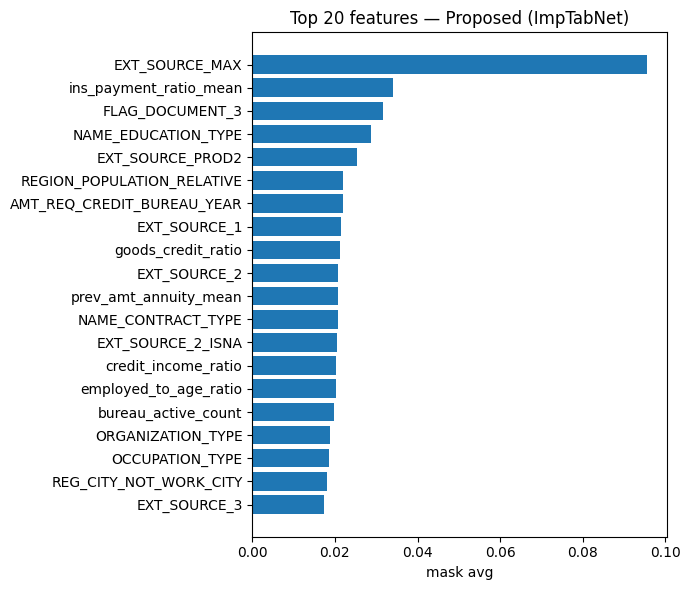

In [54]:
import torch, numpy as np, pandas as pd
import matplotlib.pyplot as plt

# Lấy model thô từ lần train final proposed (k=8, d_emb=8, seed=42)
model = raw            # 'raw' = model trả về từ train_tabnet_be; nếu tên khác, đổi lại
device = dev
model.eval()

@torch.no_grad()
def feature_importance(model, X, device, batch_size=2048):
    """Độ quan trọng = tổng mask qua step, trung bình qua mẫu & qua k sub-model."""
    if hasattr(X, 'values'): X = X.values
    X = X.astype(np.float32)
    agg = None
    n = 0
    for s in range(0, len(X), batch_size):
        xb = torch.tensor(X[s:s+batch_size]).to(device)
        mm = model.get_masks(xb)          # (steps, B, k, F)
        mm = mm.sum(0).mean(1)            # cộng step -> TB qua k -> (B, F)
        b_sum = mm.sum(0).cpu().numpy()   # cộng theo batch
        agg = b_sum if agg is None else agg + b_sum
        n += mm.shape[0]
    imp = agg / n                          # TB qua toàn bộ mẫu -> (F,)
    return imp / imp.sum()                 # chuẩn hoá về tỉ lệ (tổng = 1)

imp = feature_importance(model, X_fe_te_np, device)   # tính trên tập test

df_imp = (pd.DataFrame({'feature': FEAT_NAMES, 'importance': imp})
            .sort_values('importance', ascending=False)
            .reset_index(drop=True))

TOP = 20
# print(df_imp.head(TOP).to_string(index=False))

# Biểu đồ top-N
top = df_imp.head(TOP).iloc[::-1]
plt.figure(figsize=(7, 6))
plt.barh(top['feature'], top['importance'])
plt.xlabel('mask avg')
plt.title(f'Top {TOP} features — Proposed (ImpTabNet)')
plt.tight_layout()
plt.show()

# H. uncertainty

In [55]:
# 1) Train lại PROPOSED FINAL (k=8, PLR, d_emb=8) -> lưu vào biến RIÊNG, không để bị đè
final_cfg = {kk: v for kk, v in BASE_CFG.items() if kk not in ('seed', 'd_emb')}
final_cfg.update(best['Proposed'])
final_cfg['d_emb'] = 8

wrap_prop, _, va_m, te_m, *_ = train_tabnet_be(
    X_fe_tr_np, X_fe_va_np, X_fe_te_np,
    y_train, y_valid, y_test, bad_w,
    k=8, use_plr=True, seed=42,
    verbose_every=10**9, **final_cfg)

print("Proposed final -> valid AUC:", round(va_m['auc'],4), "| test AUC:", round(te_m['auc'],4))

# 2) KIỂM TRA uncertainty có khác 0 không TRƯỚC khi vẽ
pd_mean, pd_std = wrap_prop.predict_with_uncertainty(X_fe_te_np)   # dùng wrap_prop!
print("std: min=%.5f  median=%.5f  max=%.5f  |  %% std<1e-6: %.1f%%" % (
    pd_std.min(), np.median(pd_std), pd_std.max(), (pd_std<1e-6).mean()*100))
# std.max() PHẢI > 0 rõ rệt. Nếu max≈0 -> vẫn nhầm model k=1, dừng lại.

    Epoch   1 | valid_auc=0.64052 | 27s
  [valid] AUC=0.7835  Gini=0.5670  KS=0.4257  F1(bad)=0.2936
  [train] AUC=0.8136  Gini=0.6271  KS=0.4780  F1(bad)=0.3133
  [test] AUC=0.7866  Gini=0.5733  KS=0.4372  F1(bad)=0.2965
  Done 879.4s | Train=0.8136 | Valid=0.7835 | Test=0.7866 | Gap=0.0301
Proposed final -> valid AUC: 0.7835 | test AUC: 0.7866
std: min=0.00446  median=0.05140  max=0.26131  |  % std<1e-6: 0.0%


In [56]:
from scipy.stats import spearmanr

# Uncertainty từ proposed k=8 trên Taiwan
pd_mean, pd_std = wrap_prop.predict_with_uncertainty(X_fe_te_np)
y_te = np.asarray(y_test)
N    = len(y_te)
err  = np.abs(y_te - pd_mean)          # <-- 'err' được định nghĩa ở đây

# KIỂM std khác 0 (nếu toàn 0 -> nhầm model k=1)
print("std: min=%.5f  median=%.5f  max=%.5f  |  %% std<1e-6: %.1f%%" % (
    pd_std.min(), np.median(pd_std), pd_std.max(), (pd_std<1e-6).mean()*100))

std: min=0.00446  median=0.05140  max=0.26131  |  % std<1e-6: 0.0%


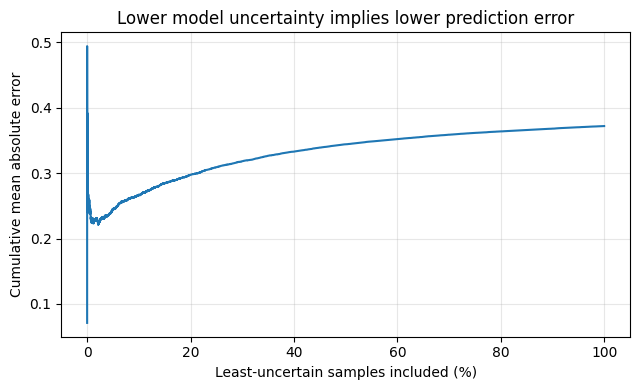

Spearman(uncertainty, error) = 0.267  (p = 0.00e+00)


In [57]:
# Cumulative mean error as we include the least-uncertain samples first
order        = np.argsort(pd_std)
err_sorted   = err[order]
cum_mean_err = np.cumsum(err_sorted) / np.arange(1, N + 1)
frac         = np.arange(1, N + 1) / N

plt.figure(figsize=(6.5, 4))
plt.plot(frac * 100, cum_mean_err, '-')
plt.xlabel('Least-uncertain samples included (%)')
plt.ylabel('Cumulative mean absolute error')
plt.title('Lower model uncertainty implies lower prediction error')
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

# Single-number evidence: rank correlation between uncertainty and error
rho, p_rho = spearmanr(pd_std, err)
print(f"Spearman(uncertainty, error) = {rho:.3f}  (p = {p_rho:.2e})")

 flag_rate  n_auto  AUC_auto
      0.00   61503    0.7866
      0.05   58428    0.7916
      0.10   55353    0.7964
      0.15   52278    0.8009
      0.20   49202    0.8046
      0.25   46127    0.8085
      0.30   43052    0.8131
      0.35   39977    0.8179
      0.40   36902    0.8242
      0.45   33827    0.8283
      0.50   30751    0.8336


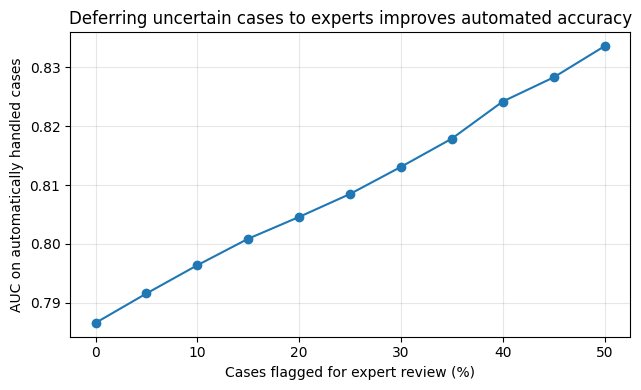

In [58]:
rates = np.arange(0, 0.55, 0.05)          # flag 0% .. 50% (x-axis sweep for the curve)
order = np.argsort(pd_std)                 # ascending uncertainty
curve = []
for r in rates:
    n_flag   = int(round(r * N))           # flag the r% most-uncertain cases
    keep_idx = order[:N - n_flag] if n_flag > 0 else order
    keep = np.zeros(N, bool); keep[keep_idx] = True
    try:
        auc_keep = roc_auc_score(y_te[keep], pd_mean[keep]) if keep.sum() > 50 else np.nan
    except ValueError:
        auc_keep = np.nan
    curve.append({'flag_rate': round(r, 2), 'n_auto': int(keep.sum()),
                  'AUC_auto': round(auc_keep, 4) if auc_keep == auc_keep else np.nan})
df_curve = pd.DataFrame(curve)
print(df_curve.to_string(index=False))

plt.figure(figsize=(6.5, 4))
plt.plot(df_curve['flag_rate'] * 100, df_curve['AUC_auto'], 'o-')
plt.xlabel('Cases flagged for expert review (%)')
plt.ylabel('AUC on automatically handled cases')
plt.title('Deferring uncertain cases to experts improves automated accuracy')
plt.grid(alpha=.3); plt.tight_layout(); plt.show()